In [2]:
import pandas as pd

# 데이터 불러오기
tr_cus_ar = pd.read_csv("data/cleaned_data.csv")

tr_cus_ar

,Unnamed: 0,t_dat,customer_id,article_id,price,sales_channel_id,FN,Active,club_member_status,age,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,0,2019-11,3e2b60b679e62fb49516105b975560082922011dd752ec...,698328010,0.016932,2,1.0,1.0,ACTIVE,51.0,...,Tops Fancy Jersey,D,Divided,2,Divided,53,Divided Collection,1005,Jersey Fancy,Top in lightweight sweatshirt fabric with drop...
1,1,2019-05,89647ac2274f54c770aaa4b326e0eea09610c252381f37...,760597002,0.033881,2,0.0,0.0,ACTIVE,28.0,...,Jersey,A,Ladieswear,1,Ladieswear,6,Womens Casual,1005,Jersey Fancy,"Short-sleeved blouse in stretch, textured jers..."
2,2,2019-05,2ebe392150feb60ca89caa8eff6c08b7ef1138cd6fdc71...,488561032,0.016932,2,1.0,1.0,ACTIVE,37.0,...,Shorts,F,Menswear,3,Menswear,21,Contemporary Casual,1025,Shorts,Knee-length shorts in soft washed cotton with ...
3,3,2019-08,7b3205de4ca17a339624eb5e3086698e9984eba6b47c56...,682771001,0.033881,2,0.0,0.0,ACTIVE,19.0,...,Bags,C,Ladies Accessories,1,Ladieswear,65,Womens Big accessories,1019,Accessories,Shopper in grained imitation leather with two ...
4,4,2019-08,3b77905de8b32045f08cedb79200cdfa477e9562429a39...,742400033,0.003220,1,0.0,0.0,ACTIVE,35.0,...,Socks Wall,F,Menswear,3,Menswear,26,Men Underwear,1021,Socks and Tights,"Socks in a soft, fine-knit cotton blend with r..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,1048570,2019-03,8e900818a1da0e73300a012794615993fbefb43f851430...,766346001,0.025407,2,0.0,0.0,ACTIVE,21.0,...,Trouser,A,Ladieswear,1,Ladieswear,15,Womens Everyday Collection,1009,Trousers,Ankle-length cigarette trousers in a stretch w...
1048571,1048571,2019-10,13aa106eeb8a6fa2f9e2ab888a3a2ee118a3900670f0d8...,811905001,0.016932,2,1.0,1.0,ACTIVE,39.0,...,Dress,A,Ladieswear,1,Ladieswear,15,Womens Everyday Collection,1013,Dresses Ladies,"Sleeveless, calf-length dress in lightly crêpe..."
1048572,1048572,2019-04,5f51e21397c1248aafdf9712435bd4be063eb093f56229...,690108001,0.021729,2,1.0,1.0,ACTIVE,44.0,...,Denim trousers,F,Menswear,3,Menswear,56,Denim Men,1016,Trousers Denim,5-pocket jeans in washed denim with a regular ...
1048573,1048573,2019-03,3421bd479ee13287a65660cf816b01d0d803d1d6d0fe73...,583534002,0.016932,2,0.0,0.0,ACTIVE,51.0,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Joggers in lightweight sweatshirt fabric with ...


c:\4team-commerce-first-project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


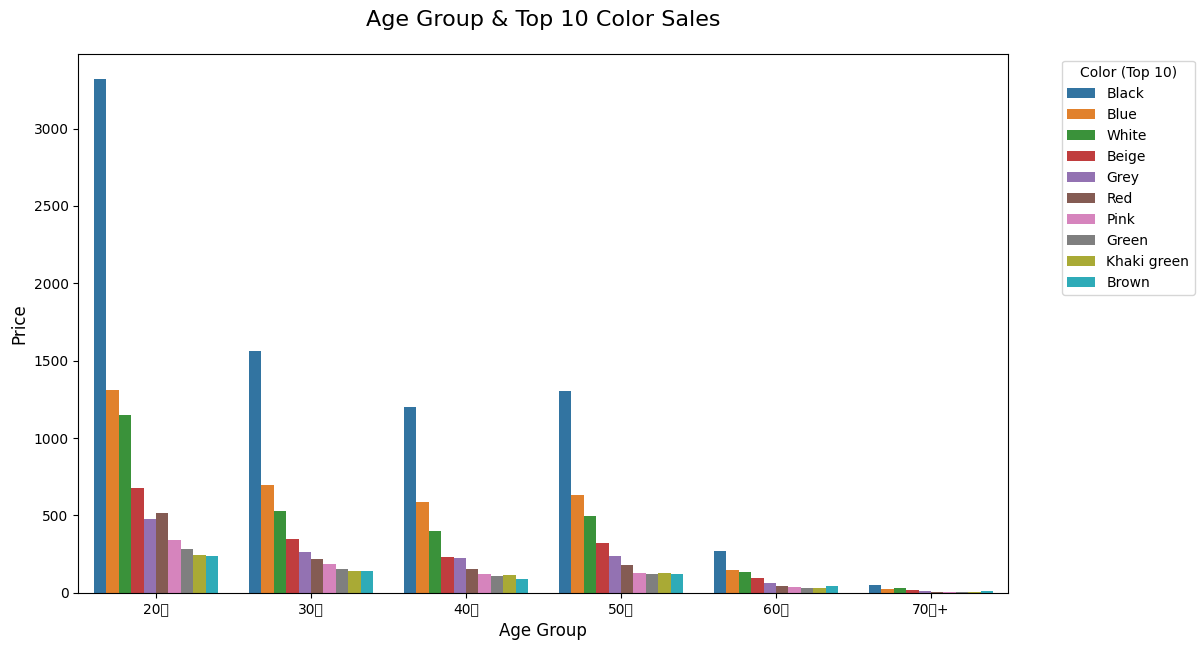

In [15]:
import matplotlib.pyplot as plt
import seaborn as sb
color_price = tr_cus_ar.groupby("perceived_colour_master_name")["price"].sum().nlargest(10).index
top10_color = tr_cus_ar[tr_cus_ar["perceived_colour_master_name"].isin(color_price)]

plt_color_age = top10_color.groupby(["age_group", "perceived_colour_master_name"])["price"].sum().reset_index()

#그래프
plt.figure(figsize=(12, 7))
# 상위 10개 색상만 포함된 데이터(plt_age_price)
sb.barplot(data=plt_color_age, x="age_group", y="price", hue="perceived_colour_master_name", hue_order=color_price)

plt.title("Age Group & Top 10 Color Sales", fontsize=16, pad=20)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.legend(title="Color (Top 10)", bbox_to_anchor=(1.05, 1), loc="upper left") # 범례를 그래프 밖으로 이동

plt.show()

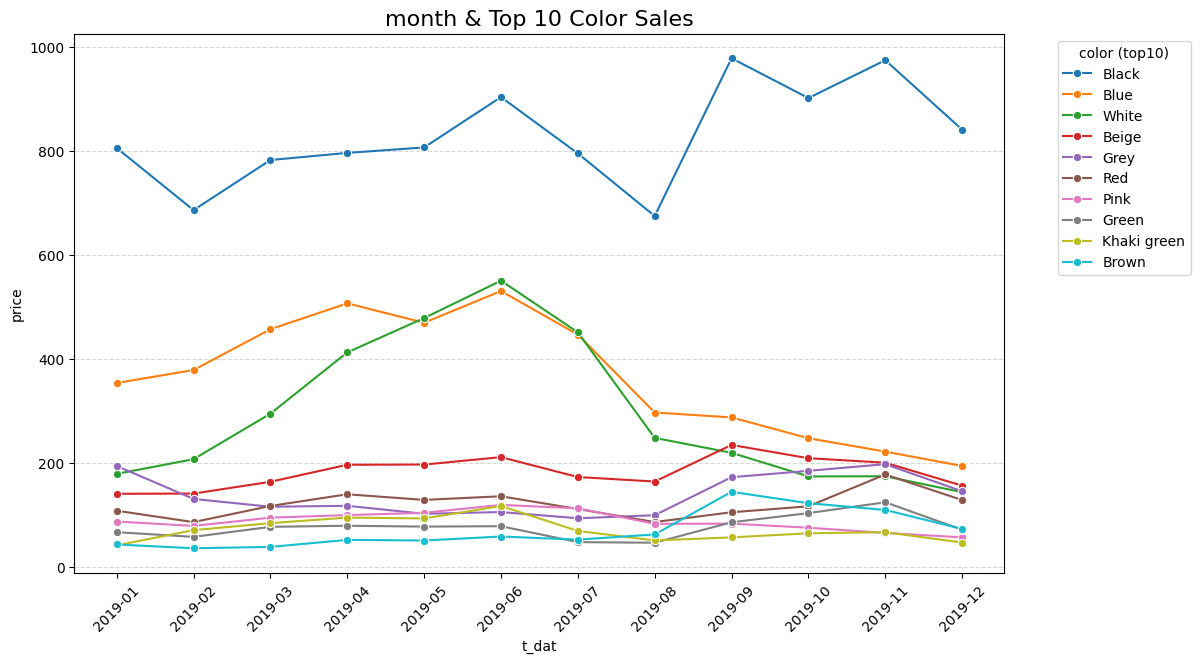

In [18]:
plt_color_month = top10_color.groupby(["t_dat", "perceived_colour_master_name"])["price"].sum().reset_index()
# (문자열로 변환 안하니까 오류나옴)
plt_color_month["t_dat"] = plt_color_month["t_dat"].astype(str)

plt.figure(figsize=(12, 7))

sb.lineplot(data=plt_color_month, 
    x="t_dat", 
    y="price", 
    hue="perceived_colour_master_name", 
    hue_order=color_price,
    marker='o')

plt.title("month & Top 10 Color Sales", fontsize=16)
plt.xticks(rotation=45) 
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(title="color (top10)", bbox_to_anchor=(1.05, 1), loc="upper left") # 범례를 그래프 밖으로 이동

plt.show()

In [5]:
# 상위 10개 색상 추출
color_price = tr_cus_ar.groupby("perceived_colour_master_name")["price"].sum().nlargest(10).index
top10_color = tr_cus_ar[tr_cus_ar["perceived_colour_master_name"].isin(color_price)]

# 나이대별 집계
plt_color_age = top10_color.groupby(["age_group", "perceived_colour_master_name"])["price"].sum()

# 월별 집계 및 문자열 변환(문자열로 변환 안하니까 오류나옴)
plt_color_month = top10_color.groupby(["t_dat", "perceived_colour_master_name"])["price"].sum().reset_index()
plt_color_month["t_dat"] = plt_color_month["t_dat"].astype(str)

plt_color_age

age_group  perceived_colour_master_name
20대        Beige                            677.020253
           Black                           3317.814097
           Blue                            1312.783116
           Brown                            235.125305
           Green                            283.118135
           Grey                             479.578406
           Khaki green                      245.117542
           Pink                             338.463236
           Red                              517.955440
           White                           1148.959387
30대        Beige                            348.421101
           Black                           1564.627523
           Blue                             693.649677
           Brown                            141.653678
           Green                            154.403356
           Grey                             265.662186
           Khaki green                      137.753559
           Pink          

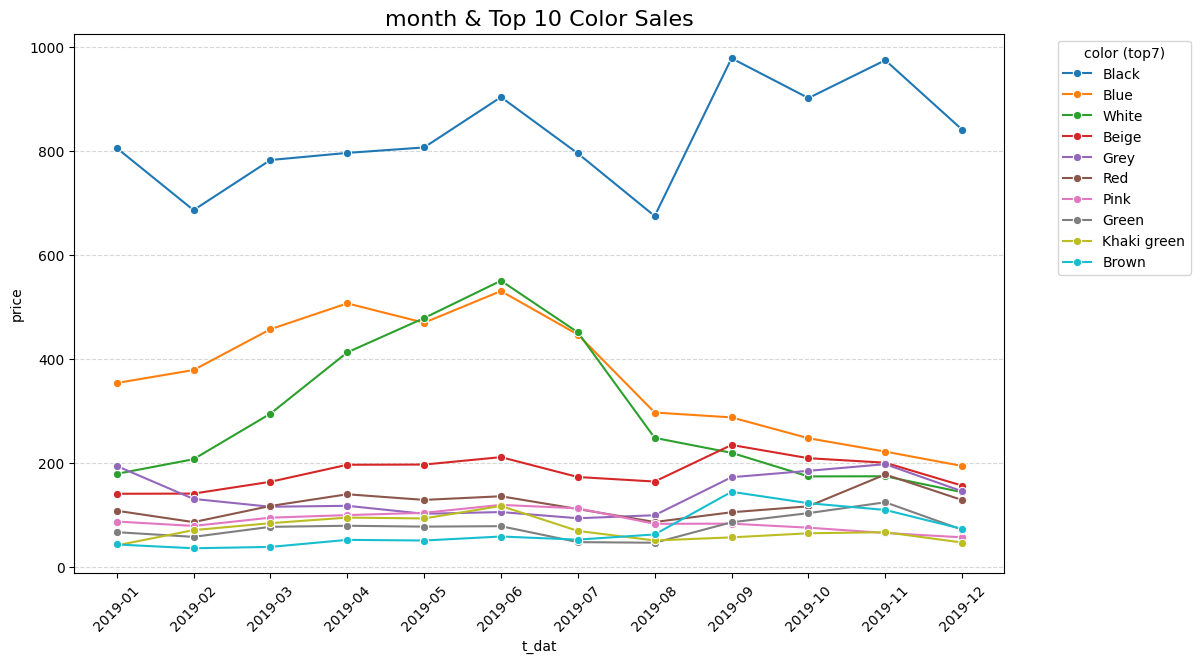

In [6]:
color_price2 = tr_cus_ar.groupby("perceived_colour_master_name")["price"].sum().nlargest(10).index
top10_color2 = tr_cus_ar[tr_cus_ar["perceived_colour_master_name"].isin(color_price)]

plt_color_age2 = top10_color2.groupby(["age_group", "perceived_colour_master_name"])["price"].sum().reset_index()

plt_color_month2 = top10_color2.groupby(["t_dat", "perceived_colour_master_name"])["price"].sum().reset_index()
# (문자열로 변환 안하니까 오류나옴)
plt_color_month2["t_dat"] = plt_color_month2["t_dat"].astype(str)

plt.figure(figsize=(12, 7))

sb.lineplot(data=plt_color_month, 
    x="t_dat", 
    y="price", 
    hue="perceived_colour_master_name", 
    hue_order=color_price2,
    marker='o')

plt.title("month & Top 10 Color Sales", fontsize=16)
plt.xticks(rotation=45) 
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(title="color (top7)", bbox_to_anchor=(1.05, 1), loc="upper left") # 범례를 그래프 밖으로 이동

plt.show()

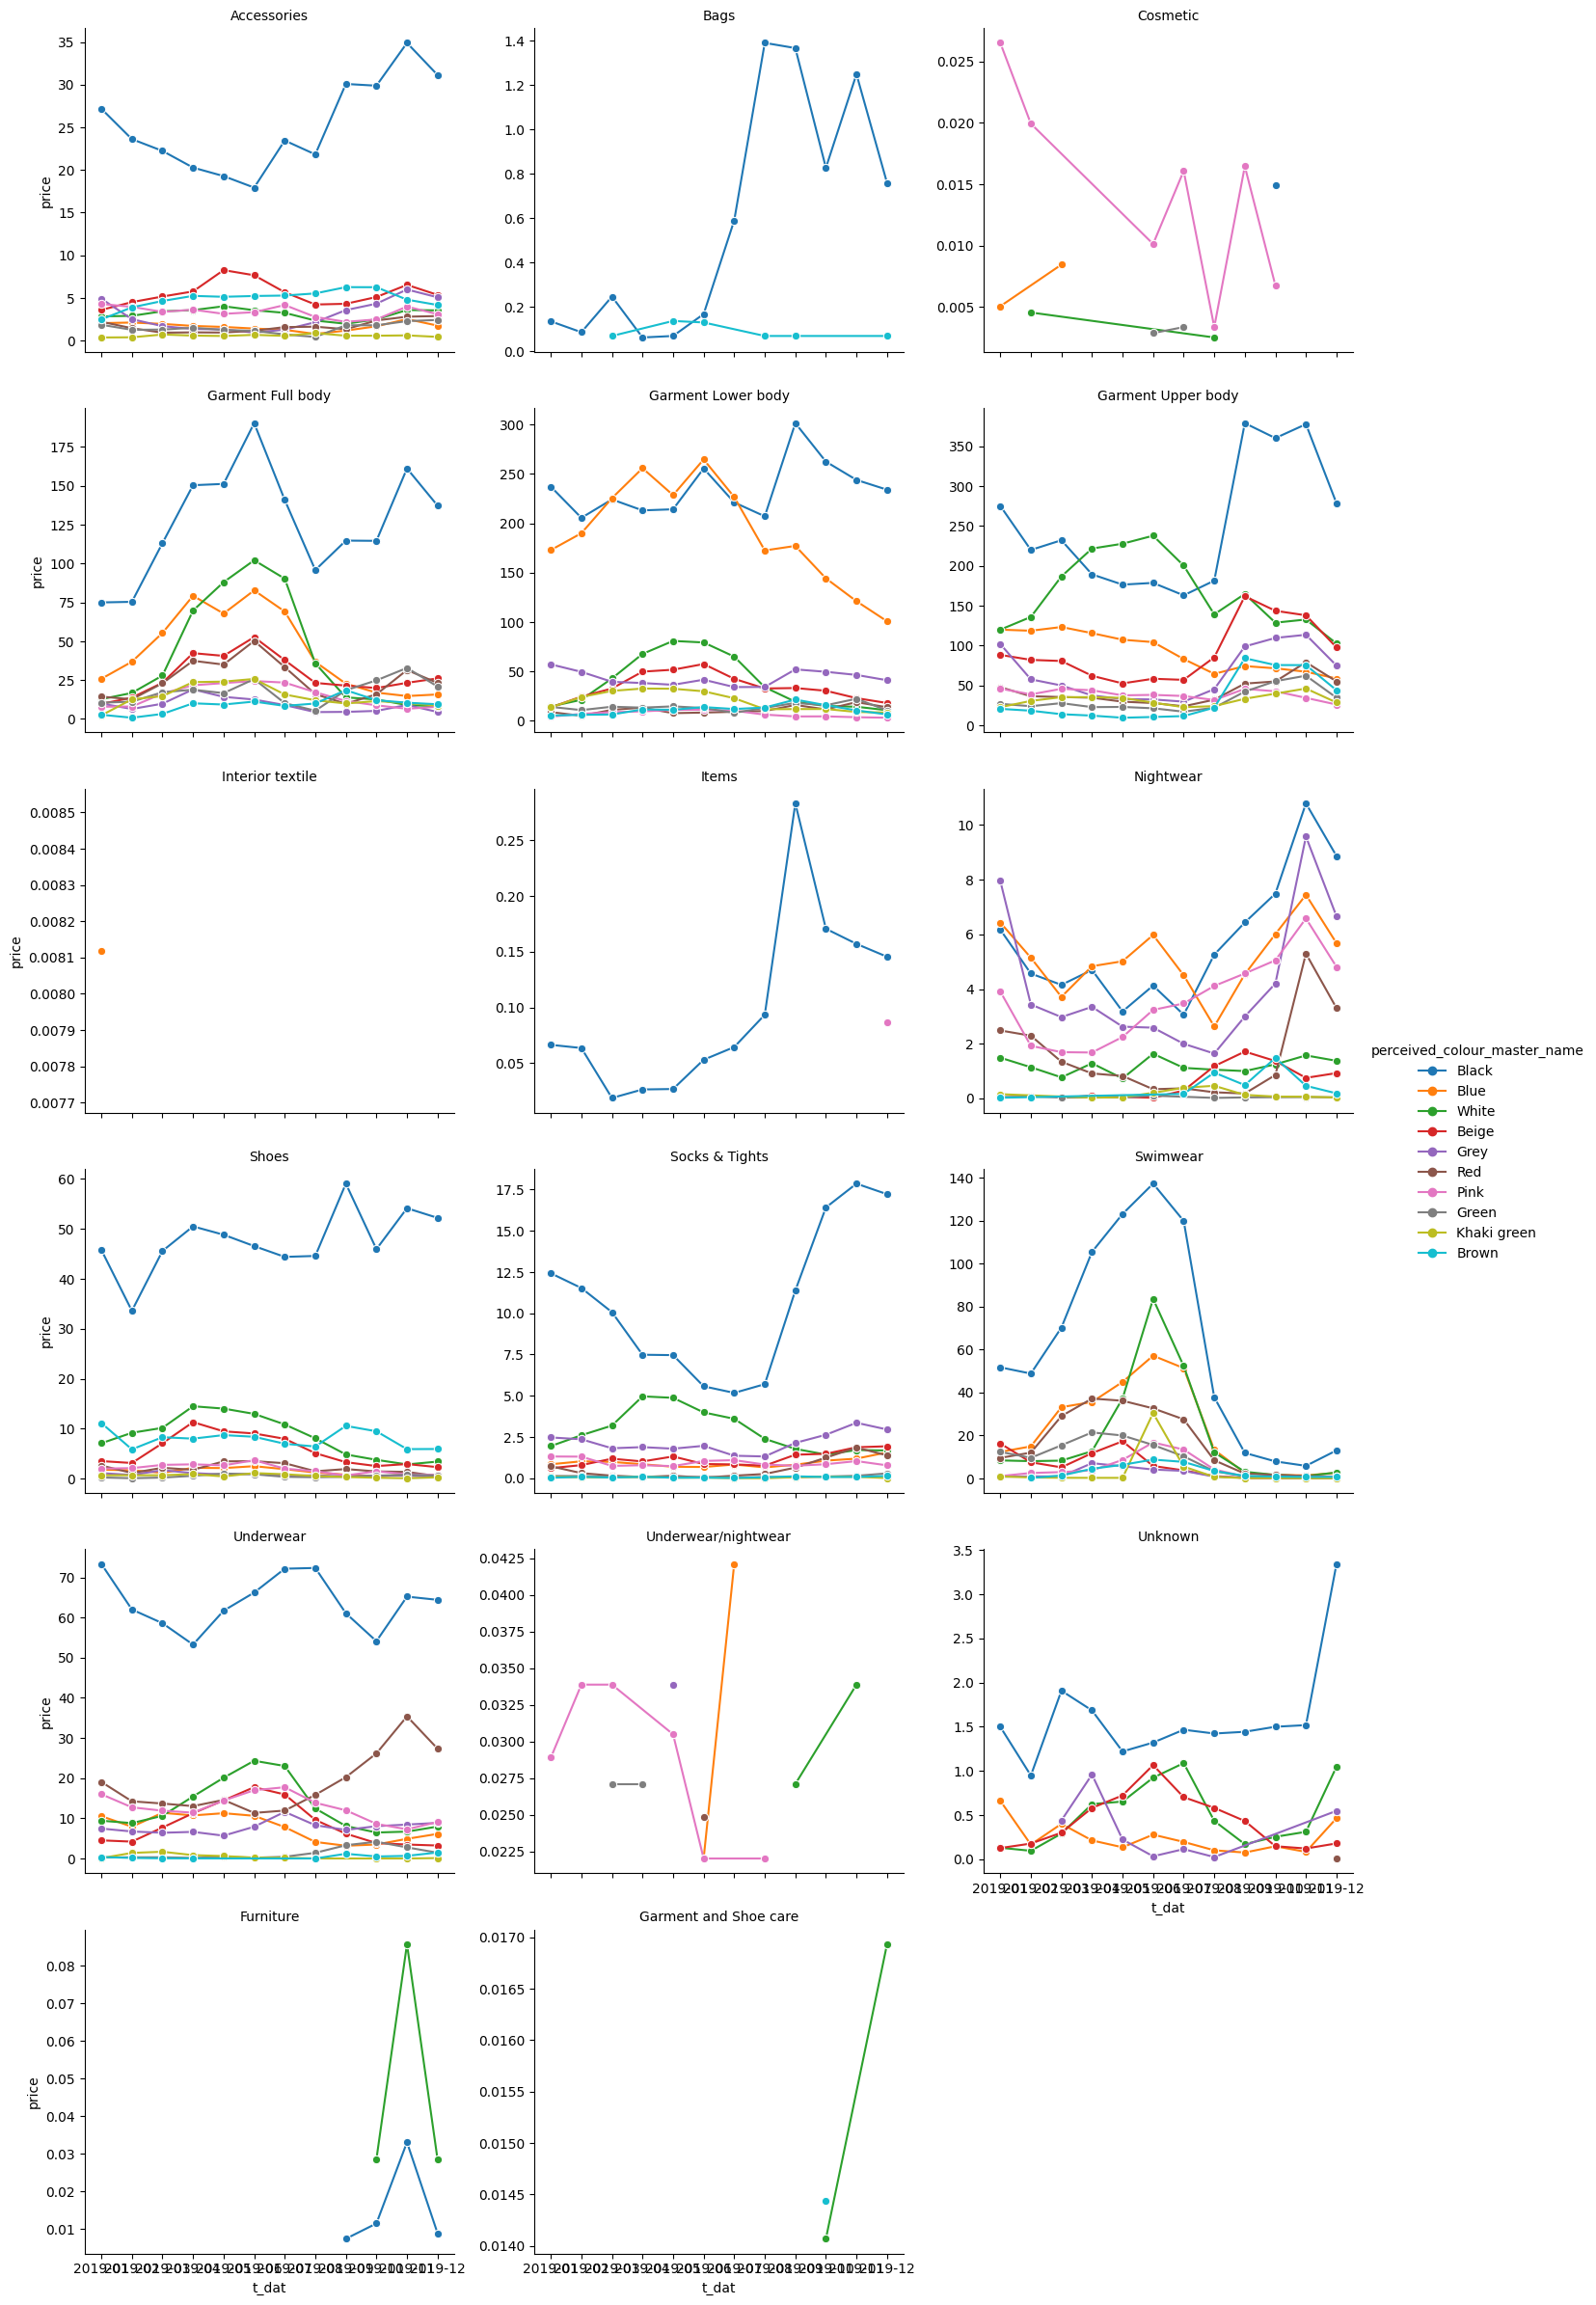

In [7]:
top10_colors2_df = tr_cus_ar[tr_cus_ar["perceived_colour_master_name"].isin(color_price2)]
# product_group_name별로 세분화하기 위해 groupby에 추가
plt_div_data = top10_colors2_df.groupby(["t_dat", "product_group_name", "perceived_colour_master_name"])["price"].sum().reset_index()
plt_div_data["t_dat"] = plt_div_data["t_dat"].astype(str)

# relplot을 이용해 product_group_name별로 그래프 생성
# col="product_group_name" 필요
prod_group_graph = sb.relplot(
    data=plt_div_data,
    x="t_dat",
    y="price",
    hue="perceived_colour_master_name",
    hue_order=color_price2,
    col="product_group_name",
    kind="line",
    marker="o",
    col_wrap=3, 
    height=4,
    aspect=1.2,
    facet_kws={'sharey': False} # 제품군마다 매출 규모가 다르므로 y축 범위를 각자 조절
)
prod_group_graph.set_titles("{col_name}") # 그래프 상단에 col="product_group_name"에 해당하는 이름표시
plt.show()

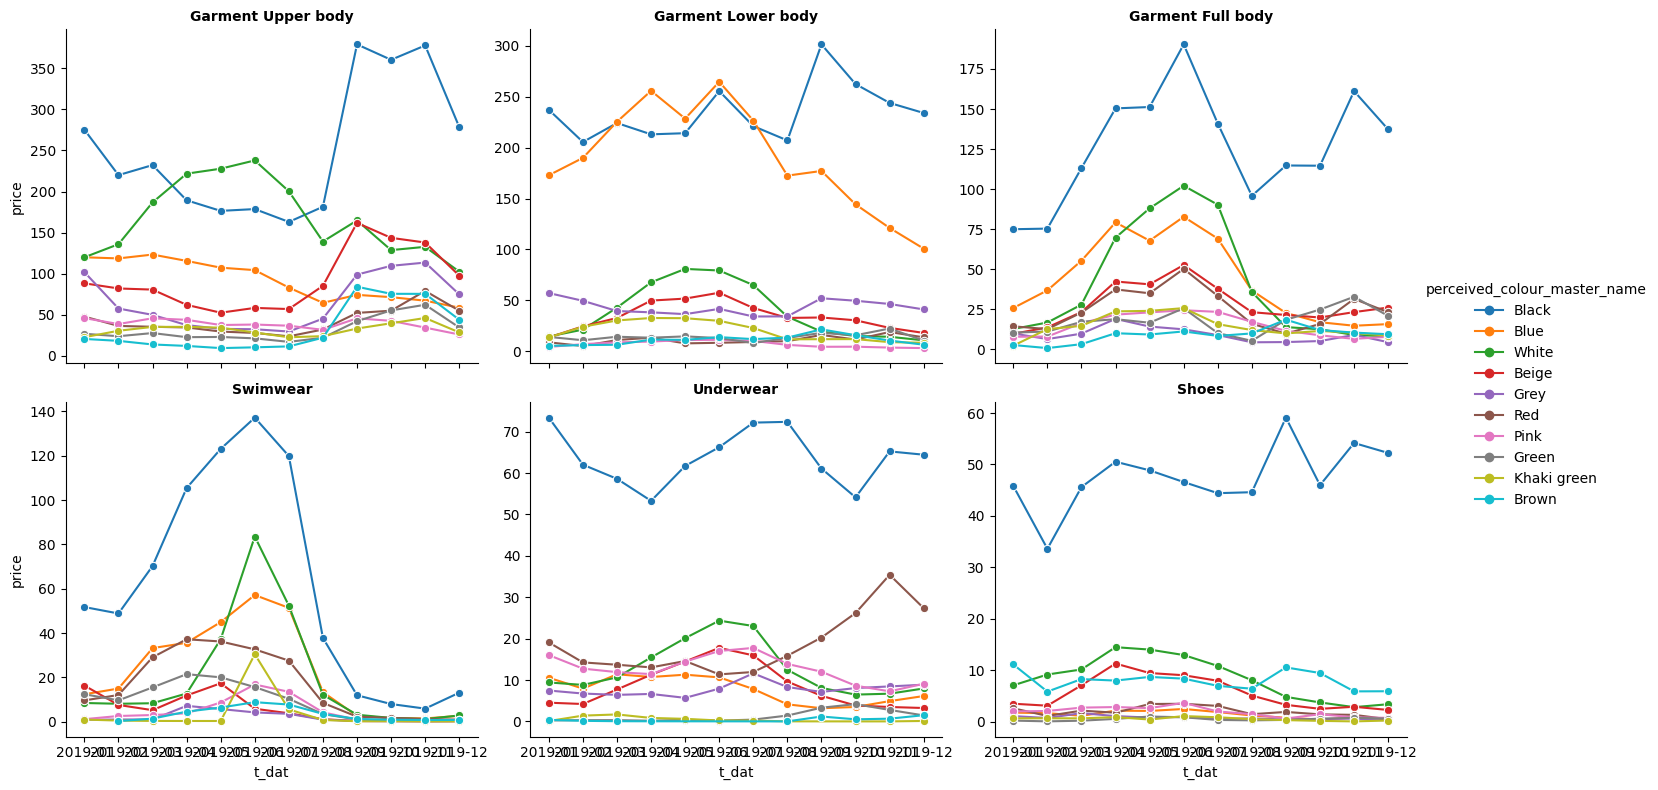

In [8]:
#상위 6개 제품군 리스트
# 매출액(price) 합계 기준 상위 6개 제품군의 이름을 가져옵니다.
top6_product_groups = (
    top10_colors2_df.groupby("product_group_name")["price"]
    .sum()
    .nlargest(6)
    .index.tolist()
)

# 데이터프레임에서 상위 6개 제품군만
top10_colors2_df = top10_colors2_df[top10_colors2_df["product_group_name"].isin(top6_product_groups)]
plt_div_data = top10_colors2_df.groupby(["t_dat", "product_group_name", "perceived_colour_master_name"])["price"].sum().reset_index()
plt_div_data["t_dat"] = plt_div_data["t_dat"].astype(str)

#relplot 그리기
g = sb.relplot(
    data=plt_div_data,
    x="t_dat",
    y="price",
    hue="perceived_colour_master_name",
    hue_order=color_price2, 
    col="product_group_name",
    col_order=top6_product_groups, # 제품군이 나오는 순서도 매출순
    kind="line",
    marker="o",
    col_wrap=3,
    height=4,
    aspect=1.2,
    facet_kws={'sharey': False}
)
g.set_titles("{col_name}", fontweight='bold') 

plt.show()

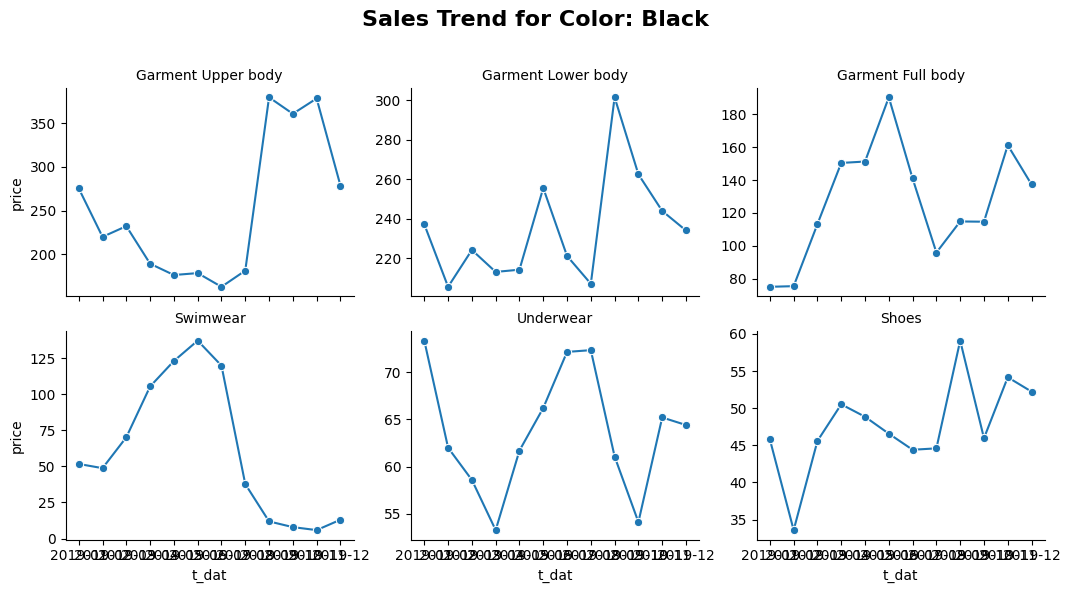

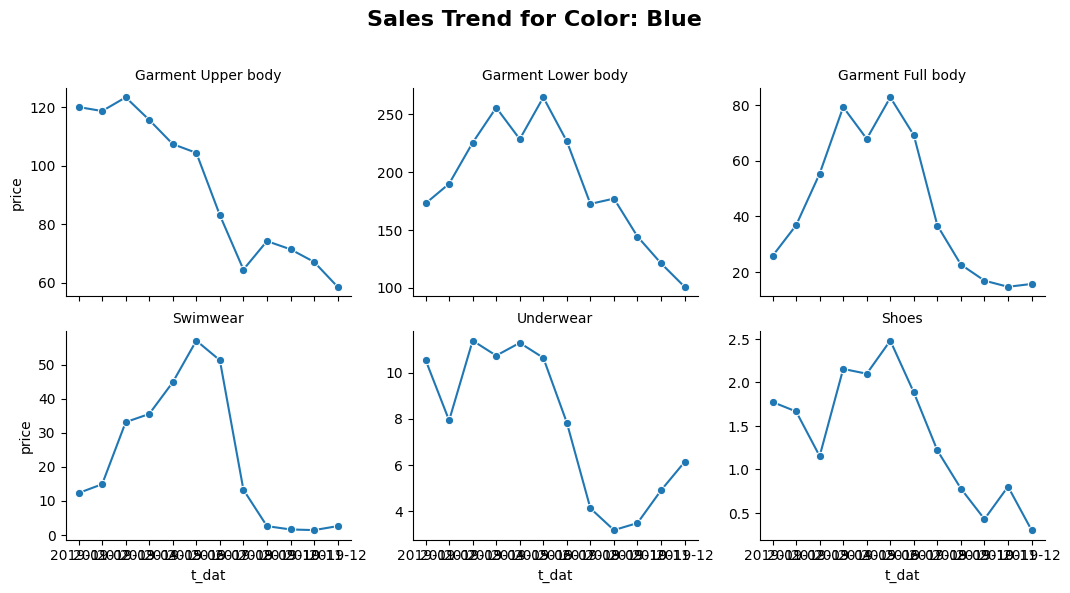

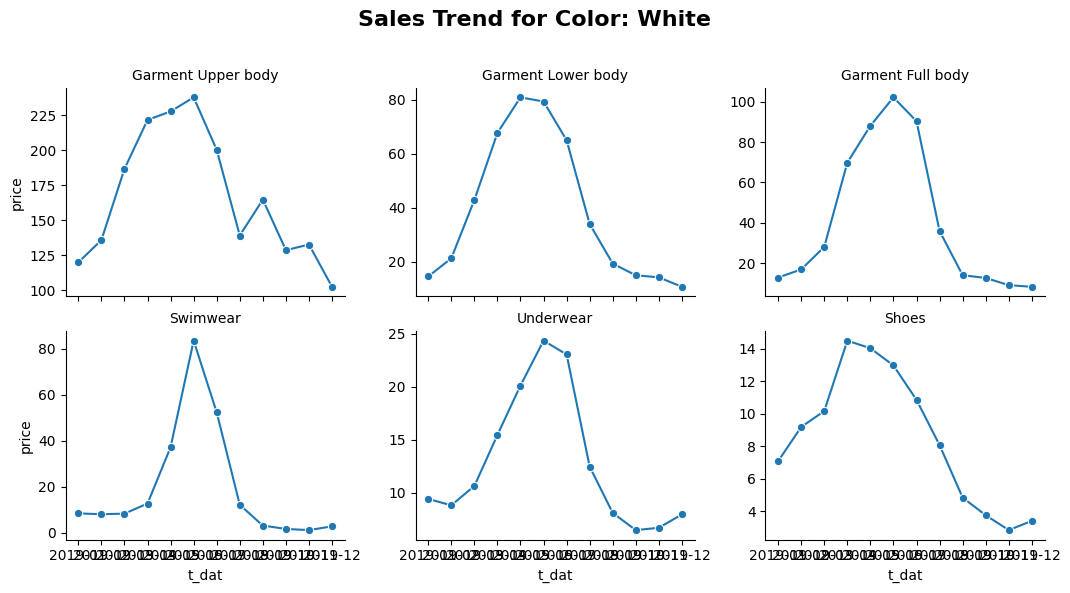

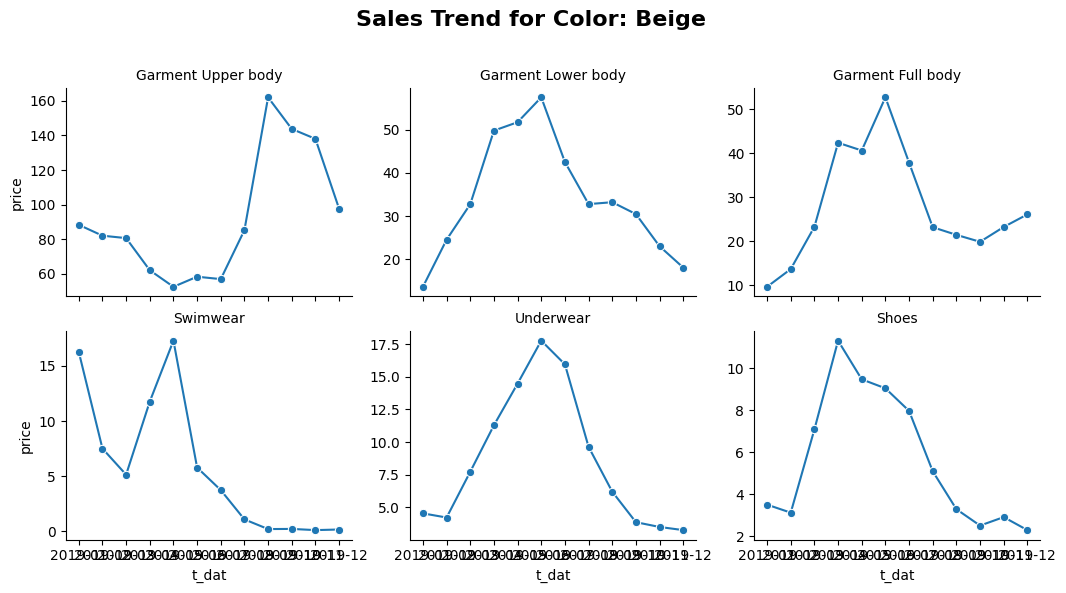

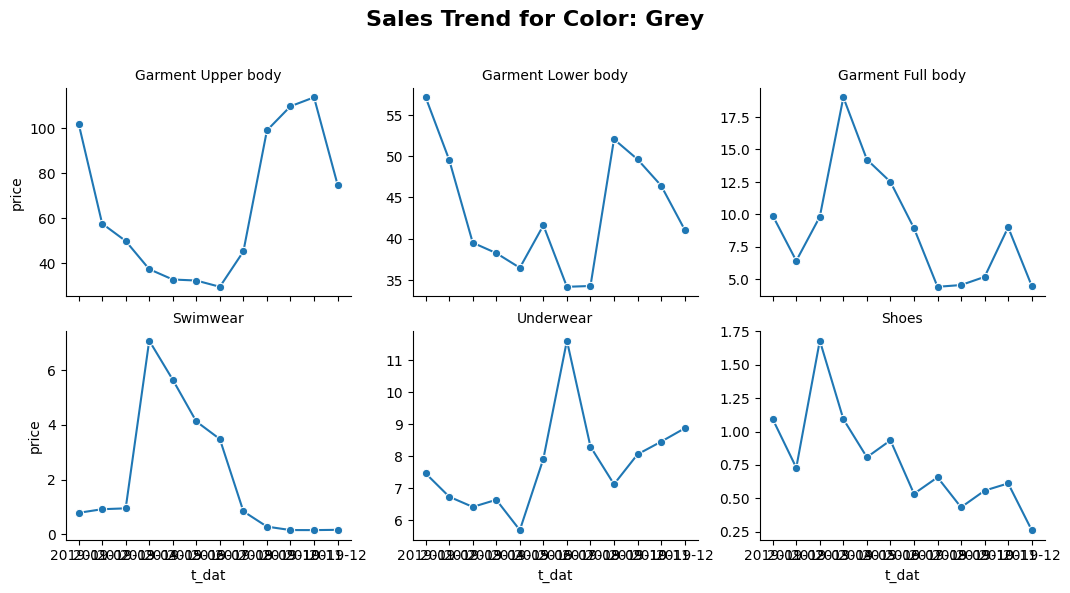

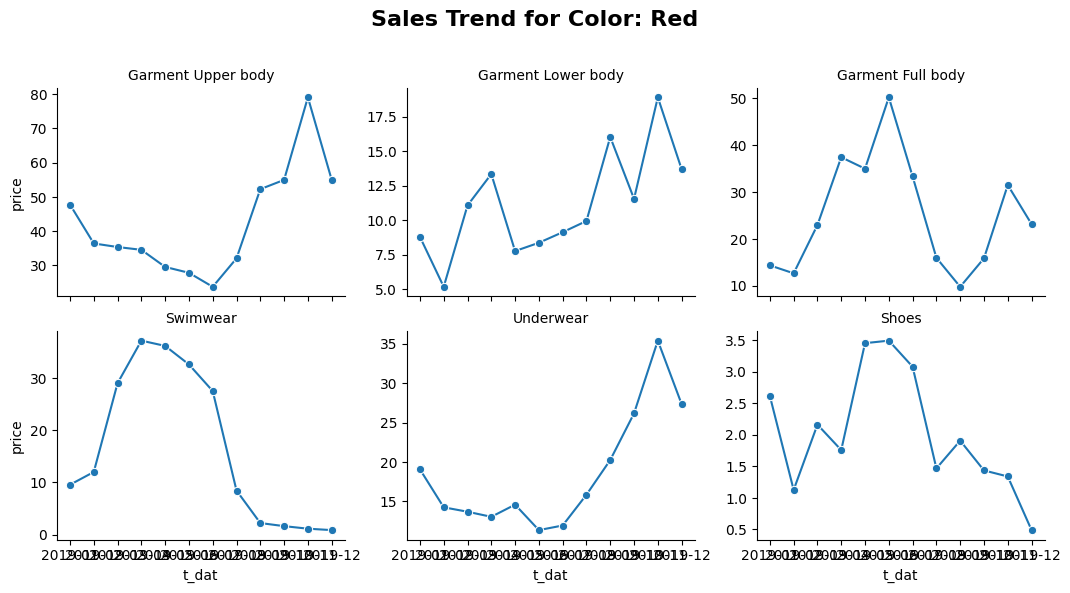

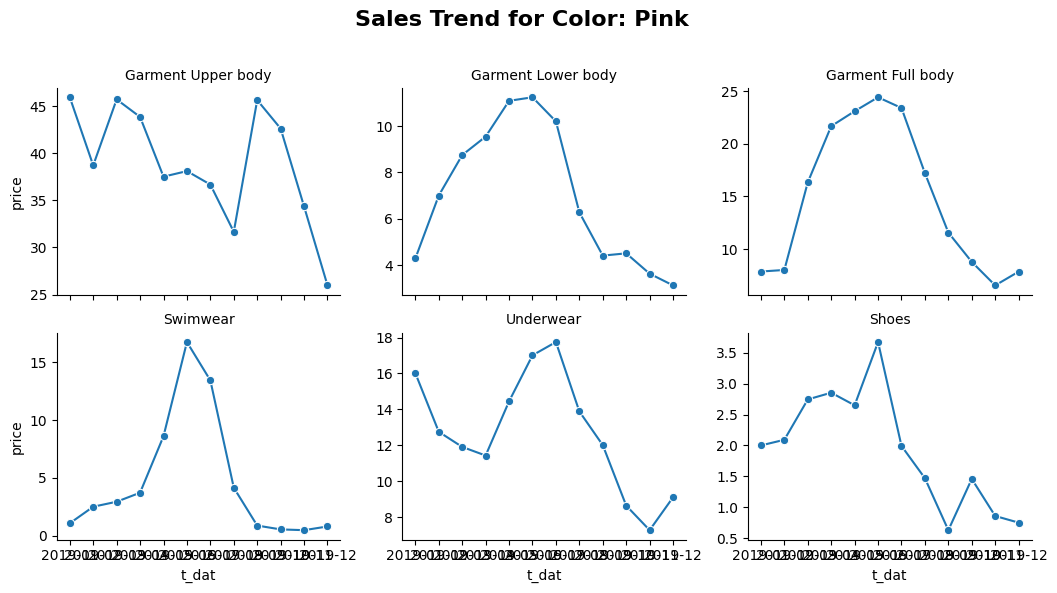

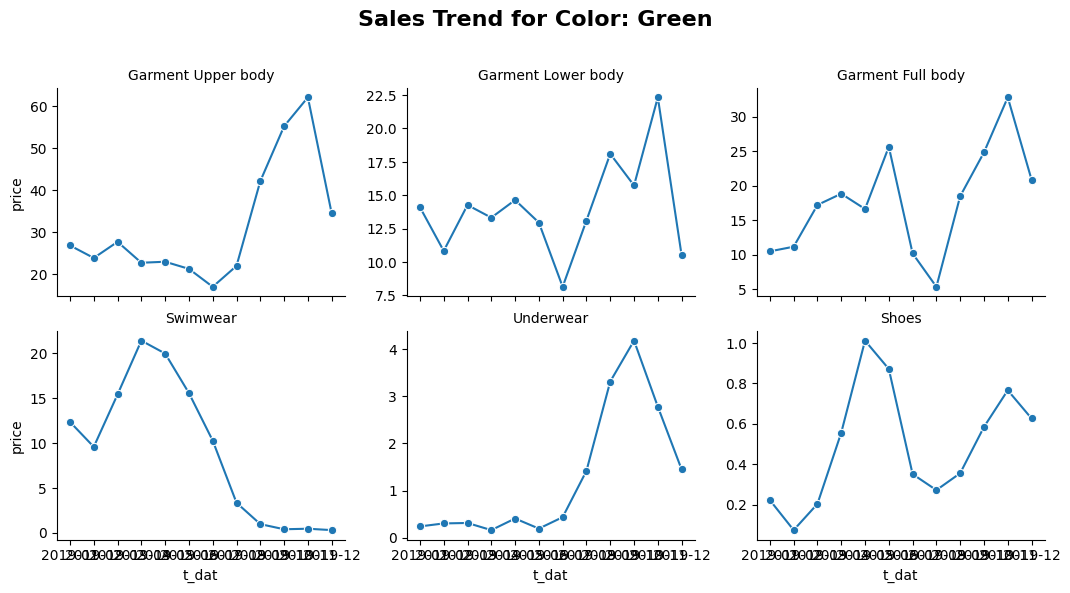

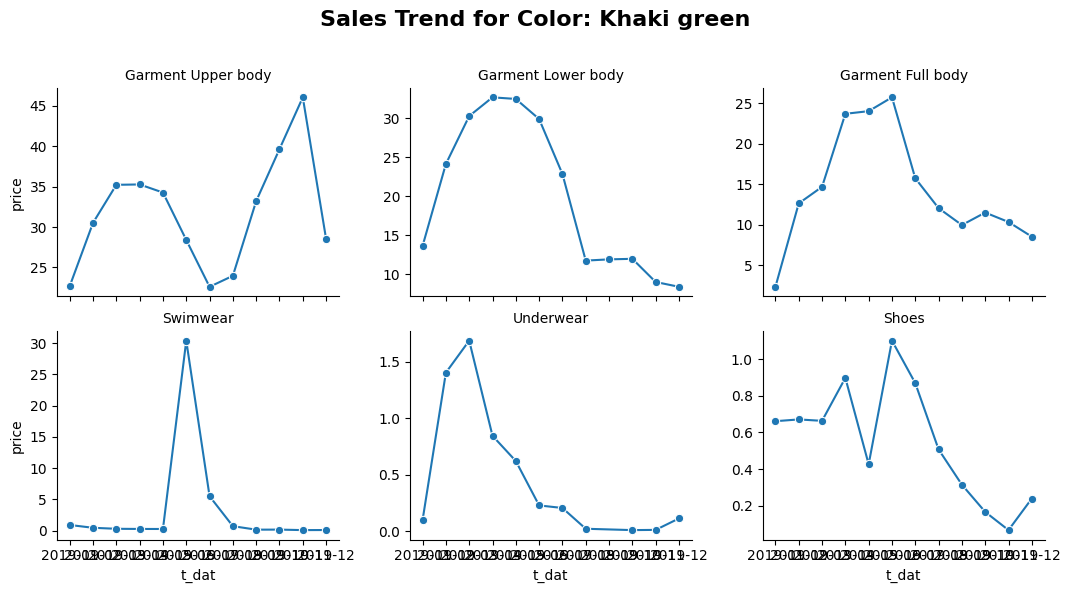

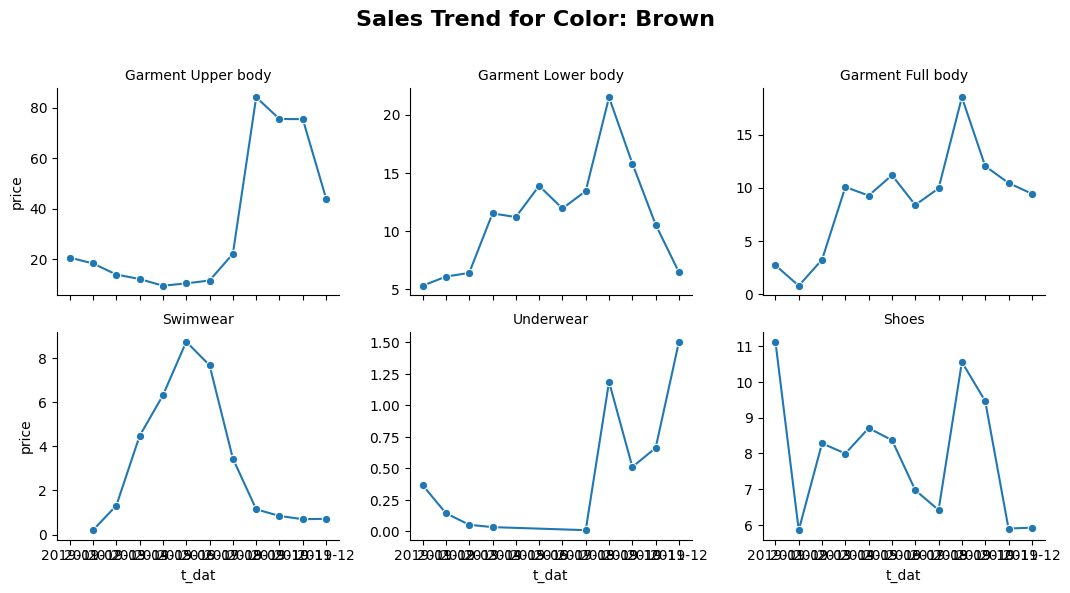

In [9]:
for color in color_price2:
    # 해당 색상의 데이터만 추출
    color_specific_data = plt_div_data[plt_div_data["perceived_colour_master_name"] == color]
       
    g = sb.relplot(
        data=color_specific_data,
        x="t_dat",
        y="price",
        col="product_group_name",
        col_order=top6_product_groups,
        kind="line",
        marker="o",
        col_wrap=3,
        height=3,
        aspect=1.2,
        facet_kws={'sharey': False}
    )
    
    # 각 색상 이름을 대제목으로 설정
    g.fig.subplots_adjust(top=0.85)
    g.fig.suptitle(f"Sales Trend for Color: {color}", fontsize=16, fontweight='bold')
    g.set_titles("{col_name}")
    
    plt.show()

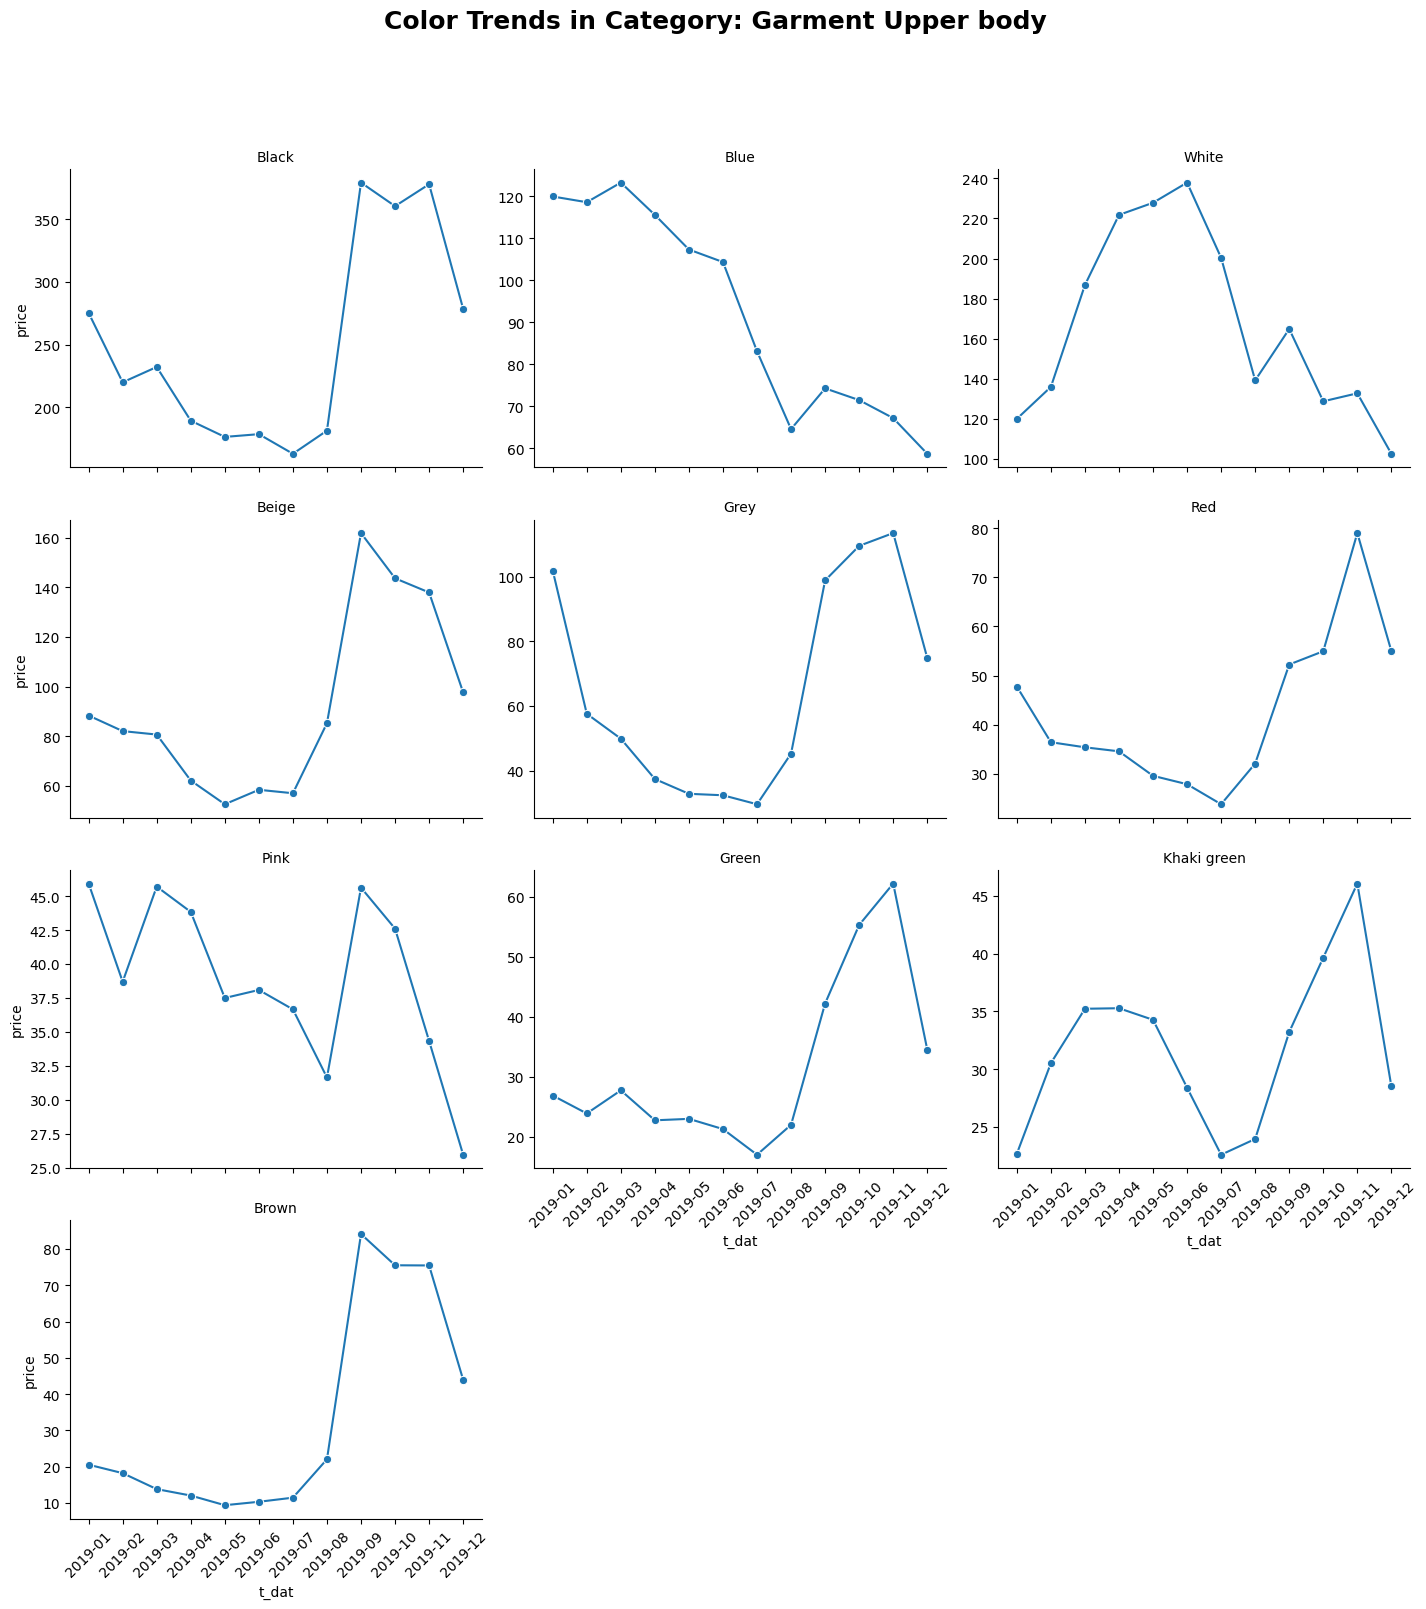

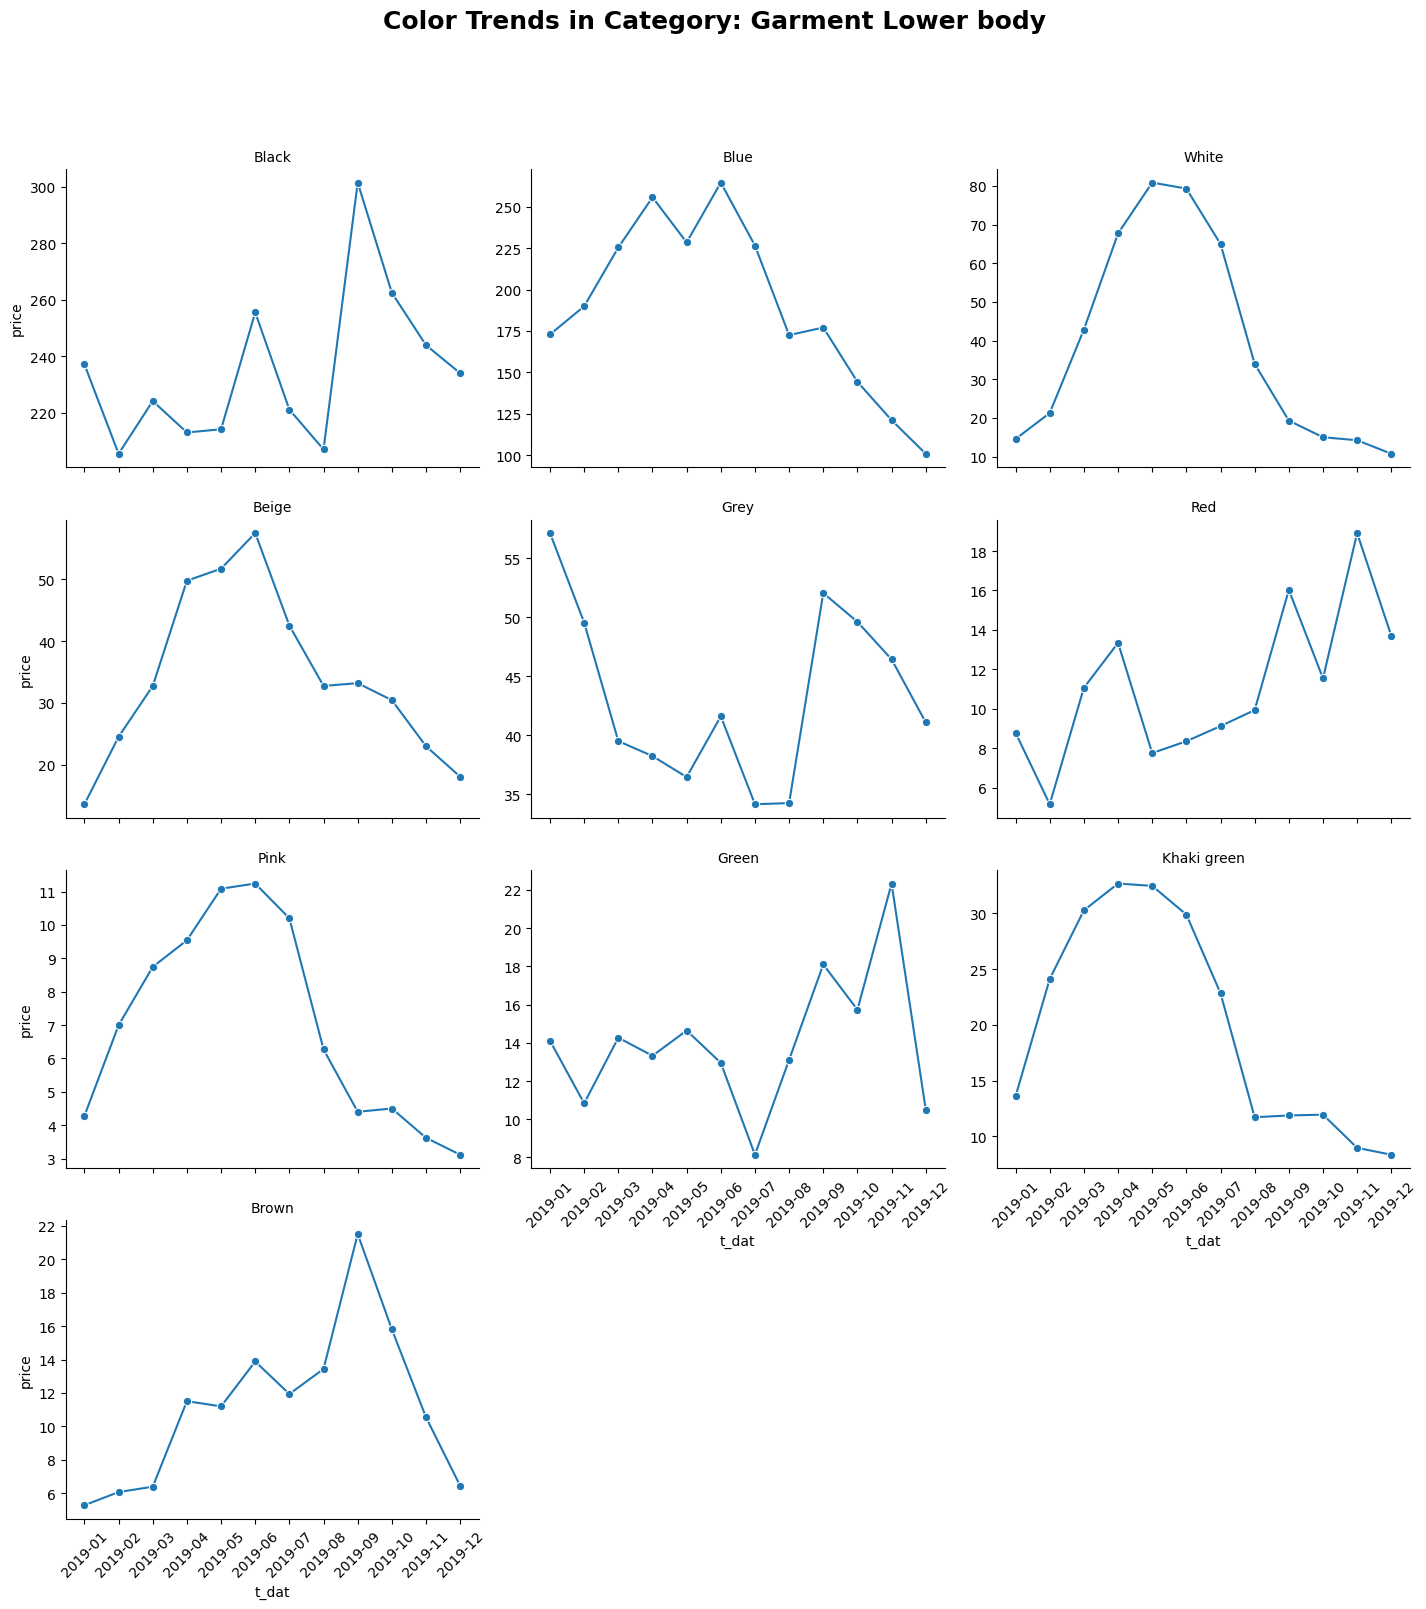

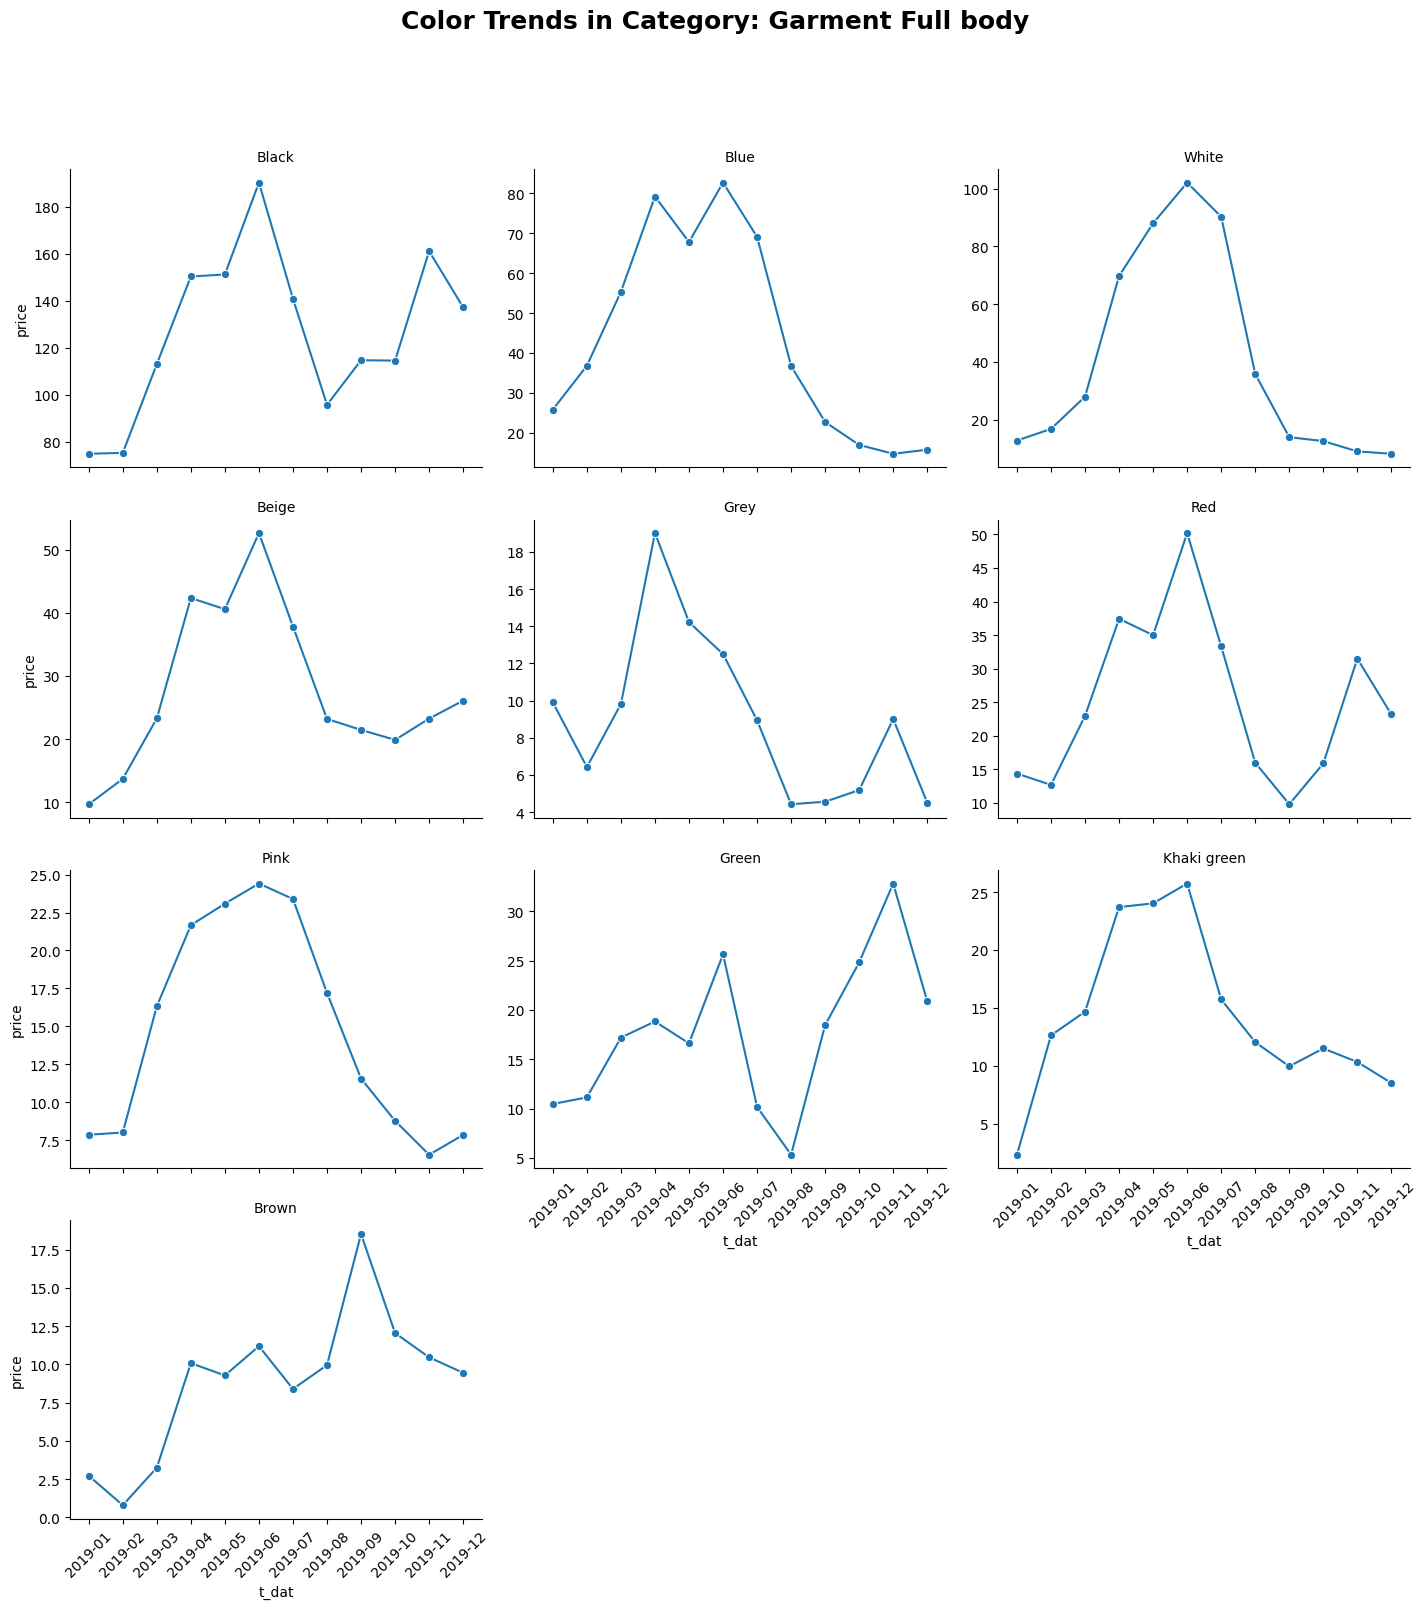

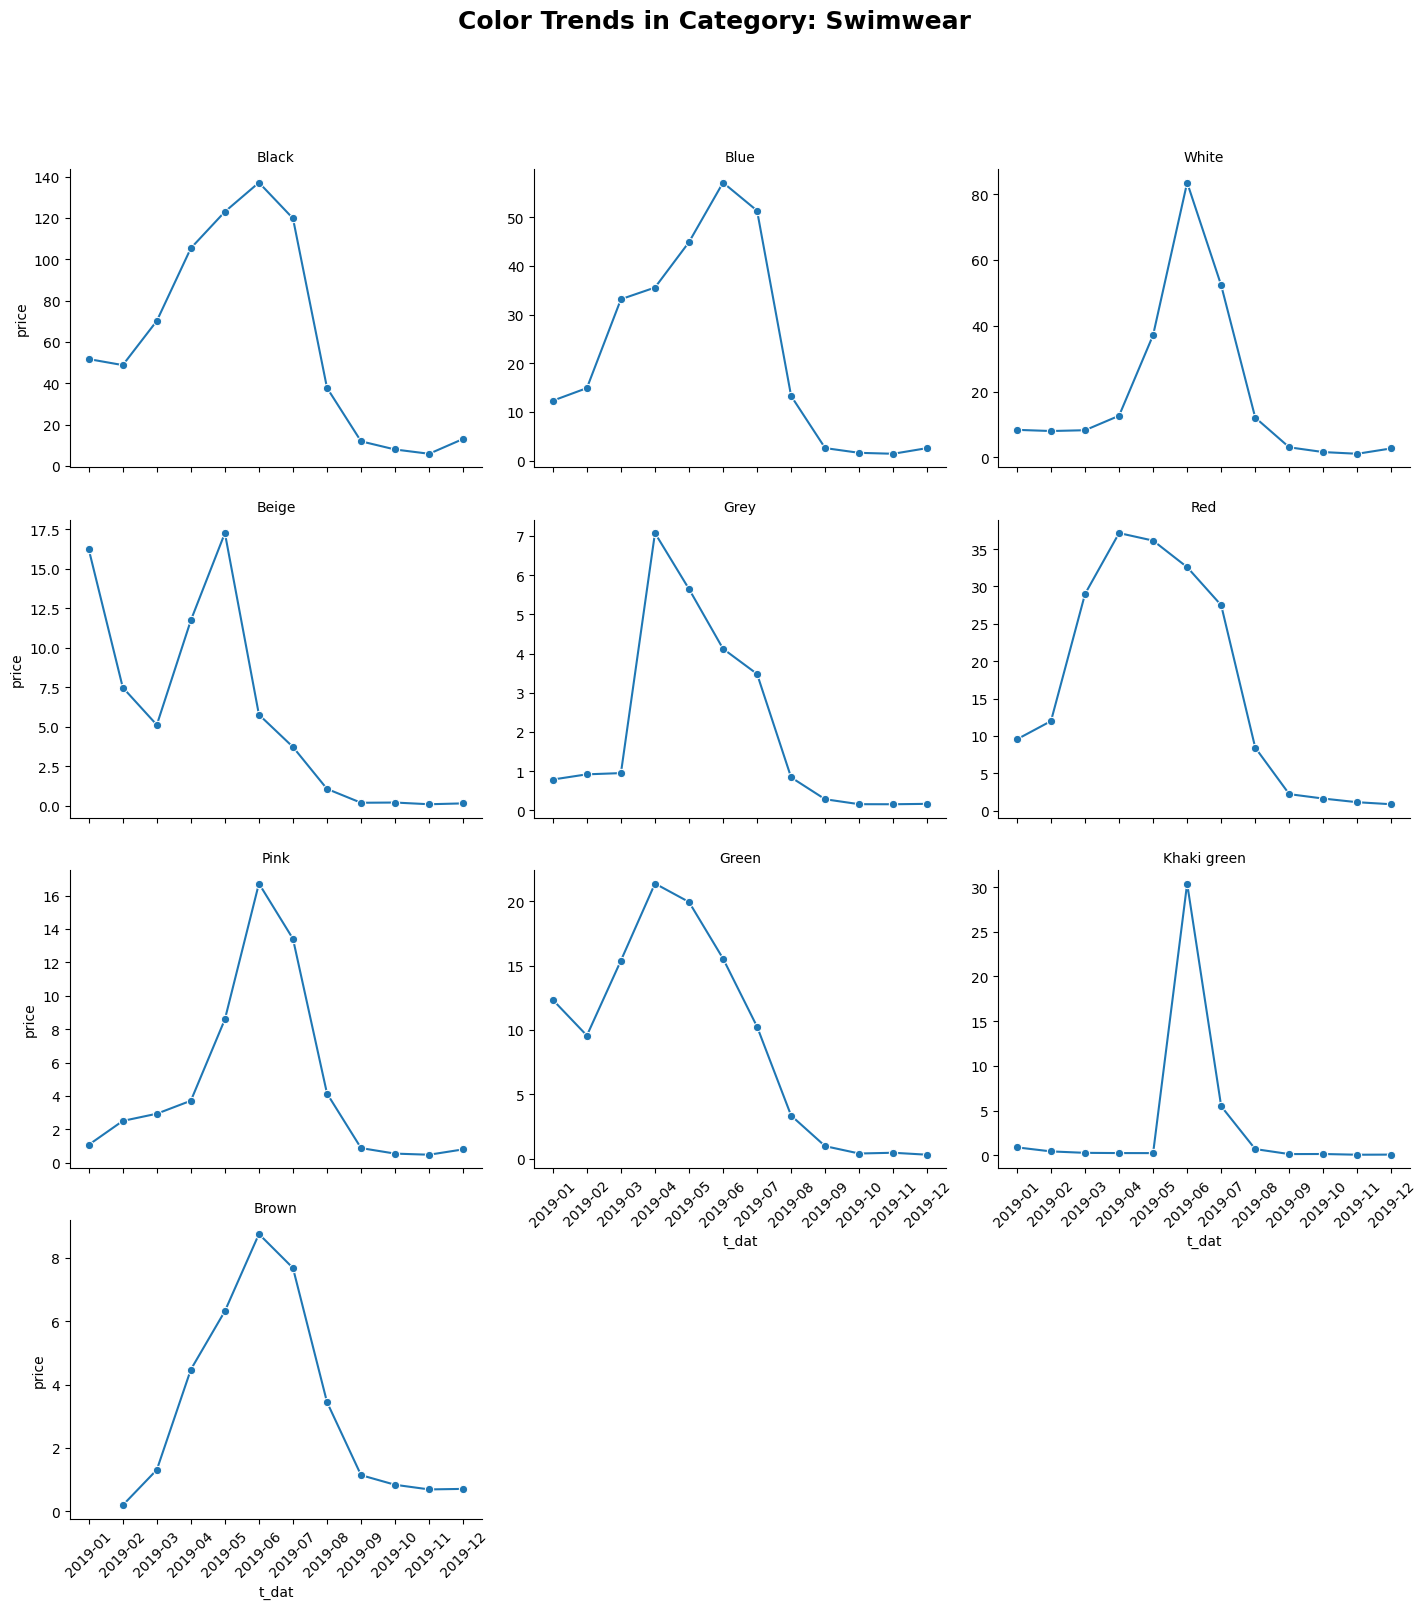

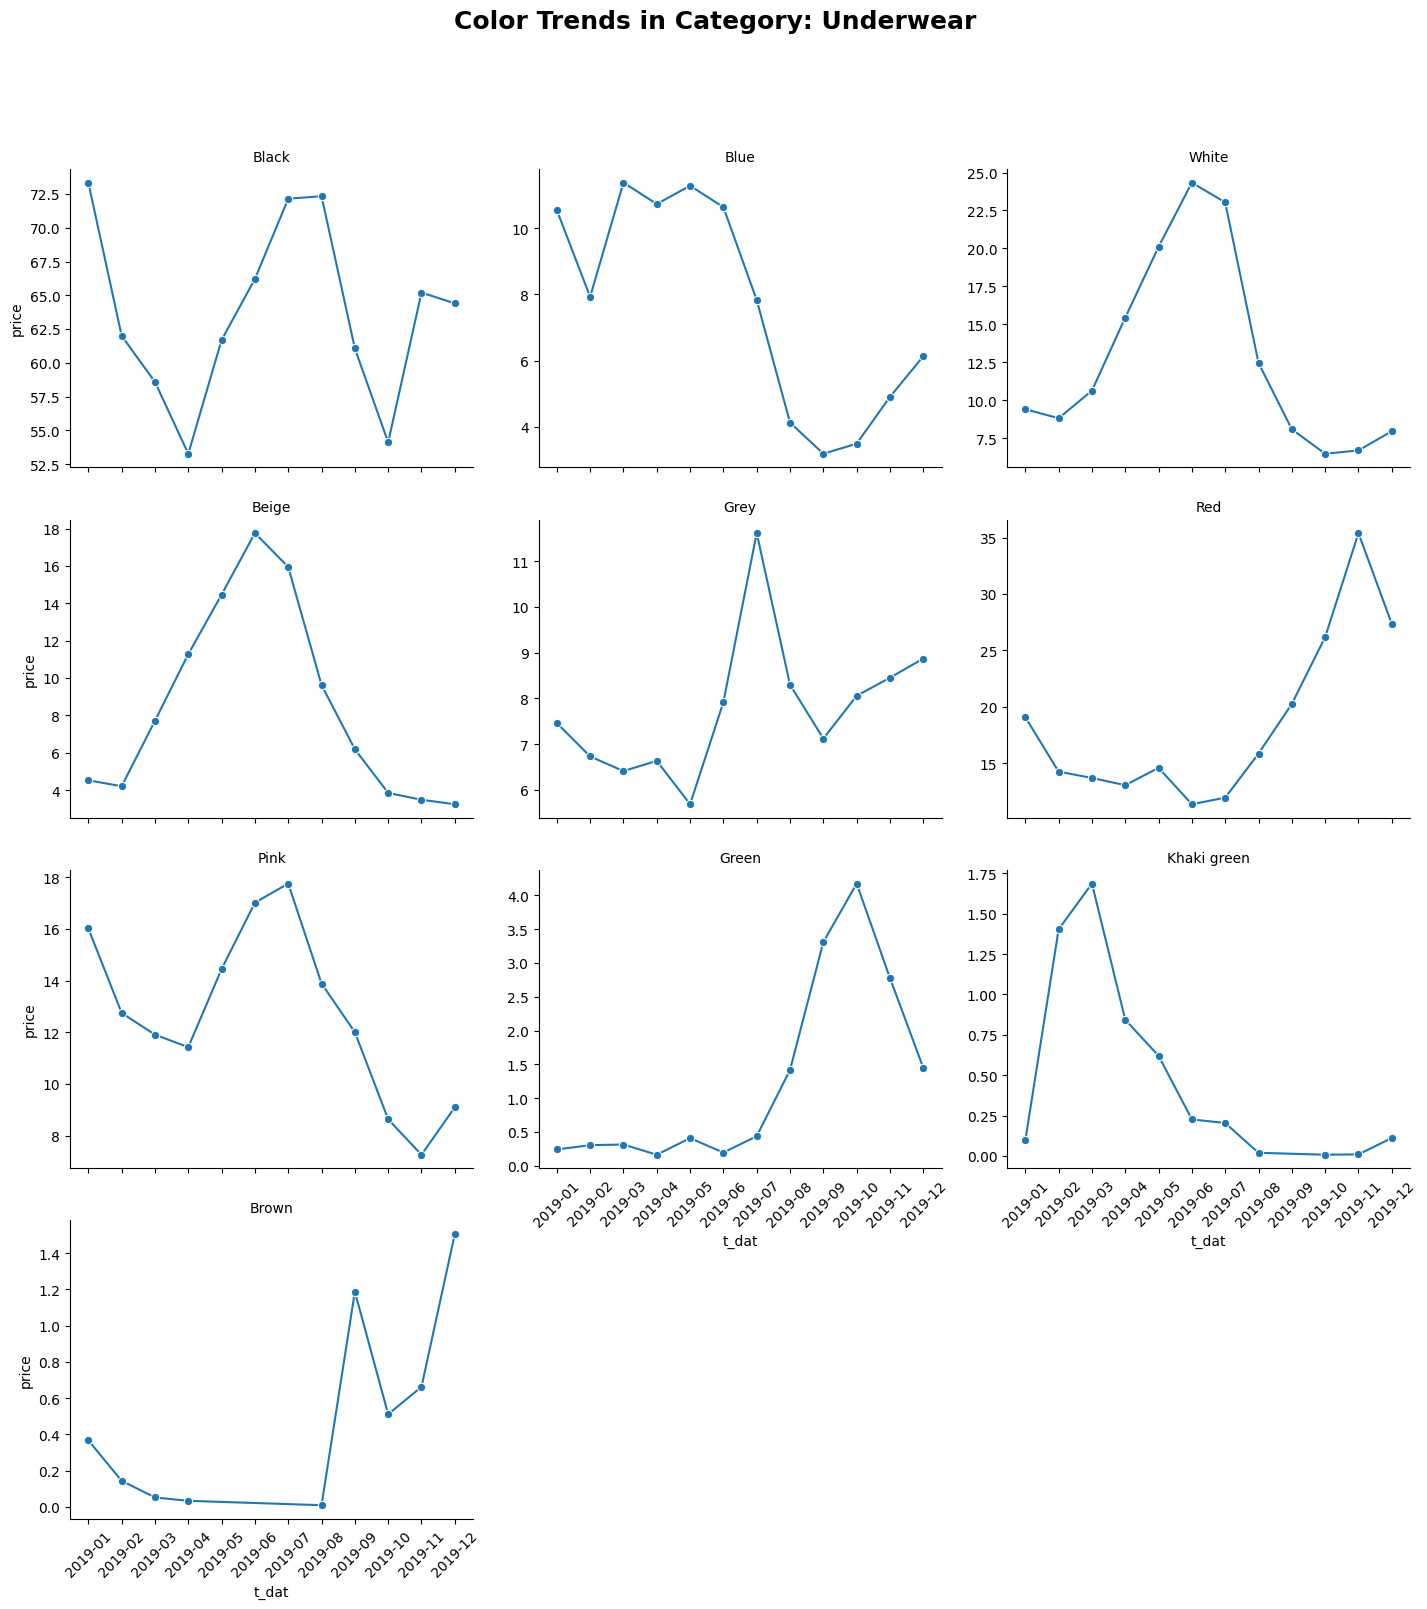

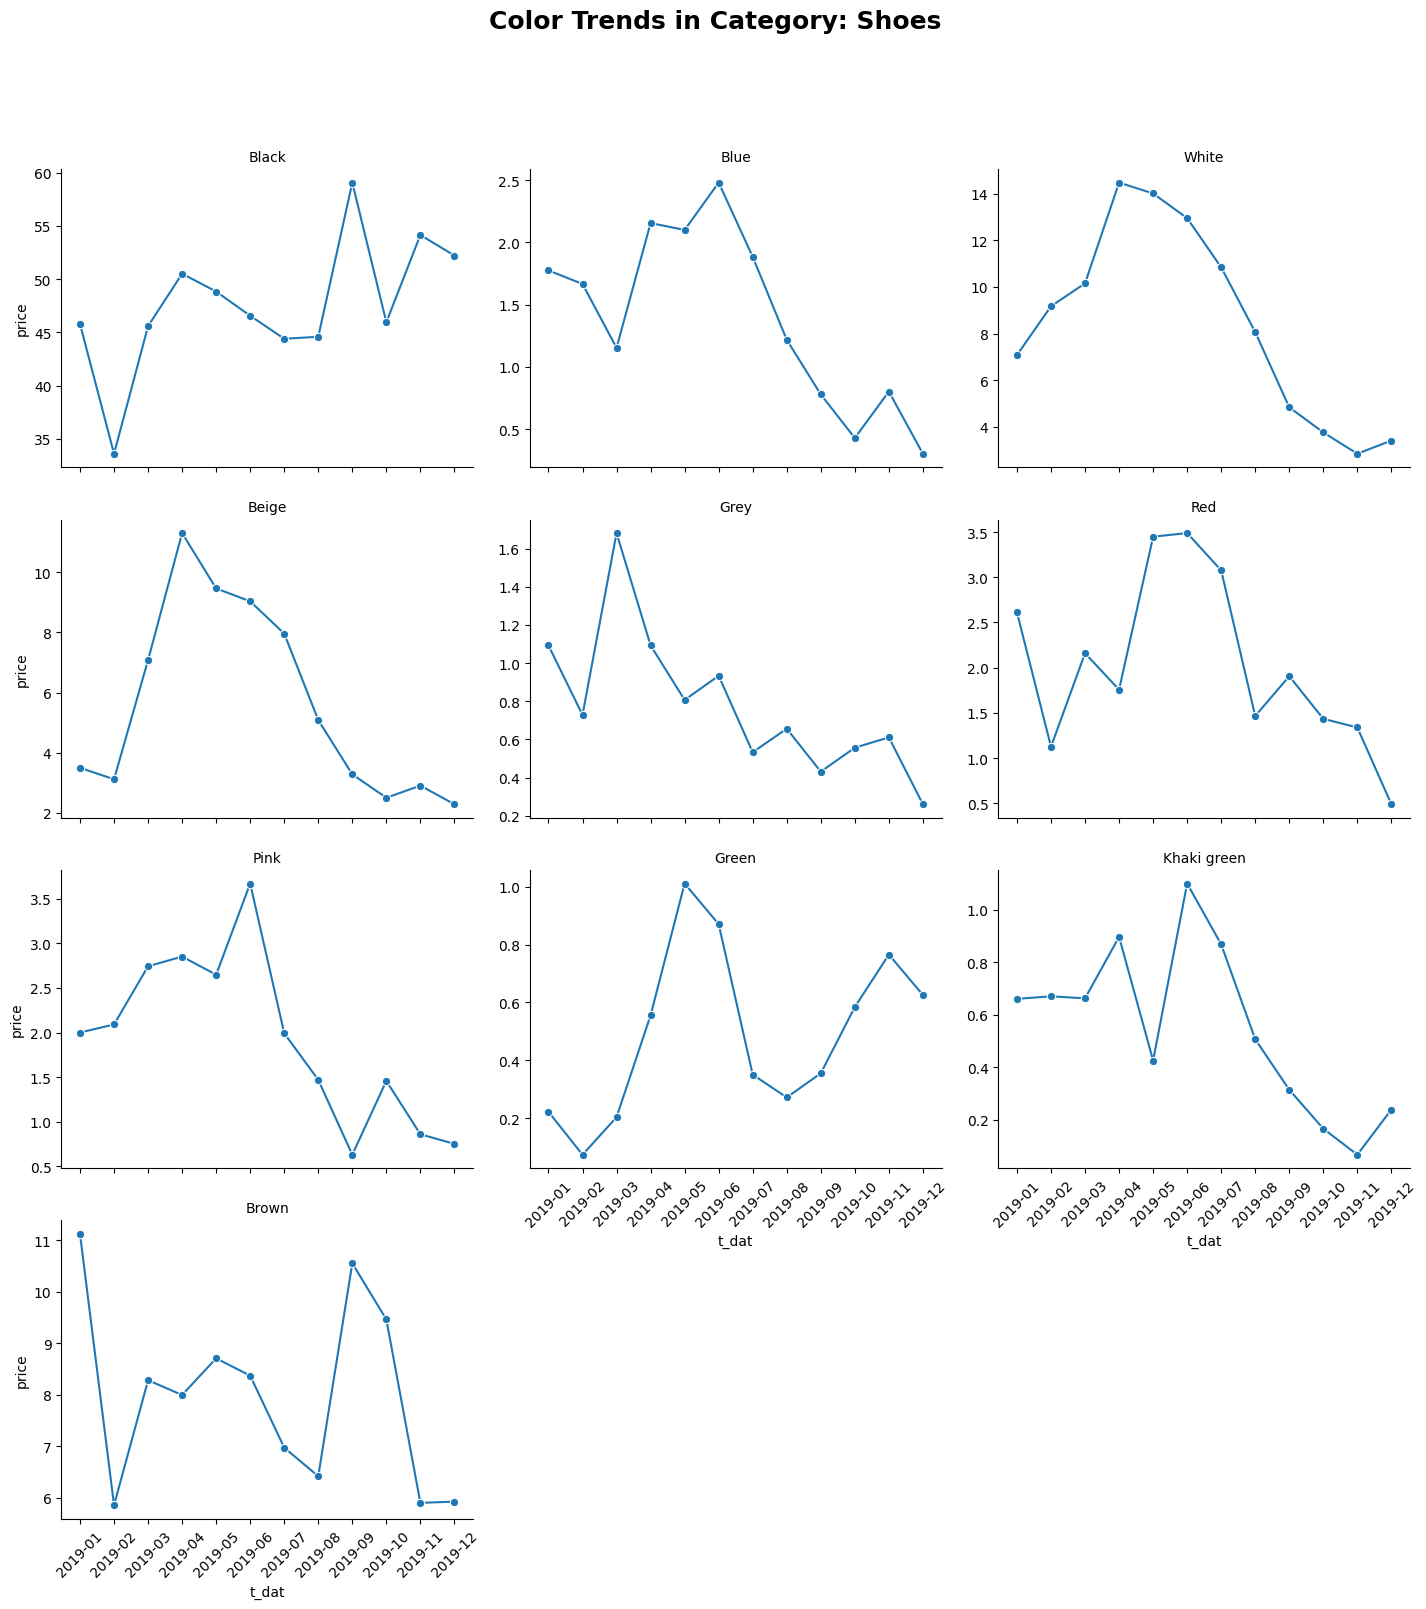

In [32]:
for category in top6_product_groups:
    
    # 해당 카테고리 데이터만 추출
    category_specific_data = plt_div_data[plt_div_data["product_group_name"] == category]
    
    # 비교하고 싶은 색상(color_price2)들만 필터링
    category_specific_data = category_specific_data[category_specific_data["perceived_colour_master_name"].isin(color_price2)]
    
    # 2. relplot 설정
    g = sb.relplot(
        data=category_specific_data,
        x="t_dat",
        y="price",
        col="perceived_colour_master_name", # 서브플롯 기준을 '색상'으로 설정
        col_order=color_price2,             # 전달받은 색상 리스트 순서대로 배치
        kind="line",
        marker="o",
        col_wrap=3,                         # 한 줄에 3개 색상씩 표시
        height=4,
        aspect=1.2,
        facet_kws={'sharey': False}         # 색상별로 가격대가 달라도 잘 보이도록 설정
    )
    
    # 3. 전체 그래프 제목 및 레이아웃
    g.fig.subplots_adjust(top=0.88)
    g.fig.suptitle(f"Color Trends in Category: {category}", fontsize=18, fontweight='bold')
    g.set_titles("{col_name}") # 서브플롯 상단에 색상 이름 표시
    
    # x축 날짜 라벨 회전
    for ax in g.axes.flat:
        ax.tick_params(axis='x', labelrotation=45)
    
    plt.show()

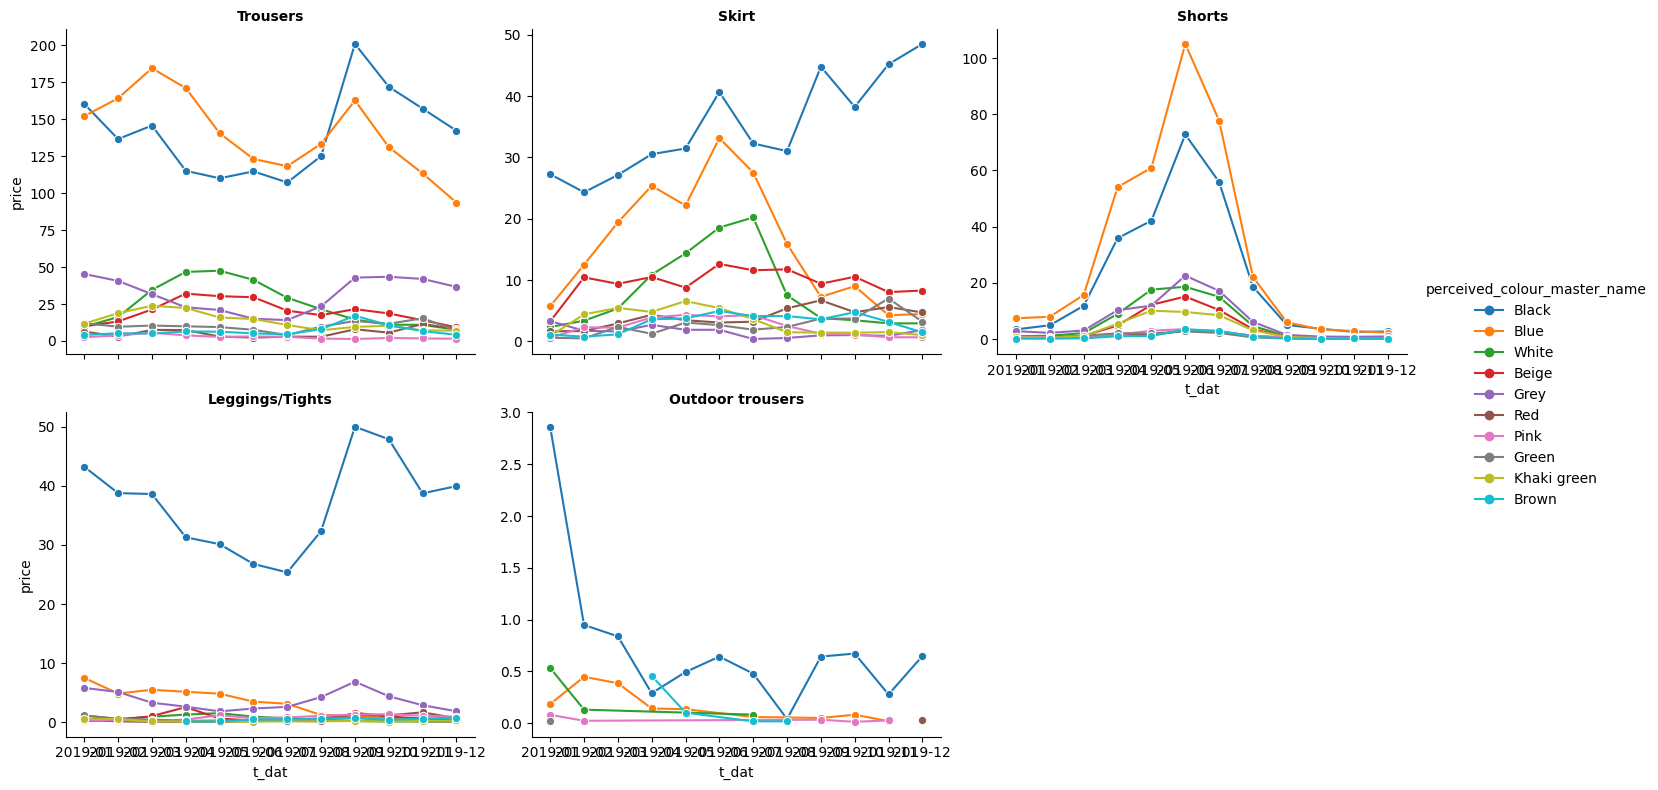

In [10]:
# Garment Lower body만 추출
lower_body_df = tr_cus_ar[tr_cus_ar["product_group_name"] == "Garment Lower body"].copy()

# Garment Lower body 상위 5개 product_type_name 리스트로
top6_lower_types = (
    lower_body_df.groupby("product_type_name")["price"]
    .sum()
    .nlargest(5)
    .index.tolist()
)

# type_name 상위 5개만
lower_body_top6 = lower_body_df[lower_body_df["product_type_name"].isin(top6_lower_types)]

# 월별, type_name, 색상별 데이터 집계
plt_lower_data = lower_body_top6.groupby(["t_dat", "product_type_name", "perceived_colour_master_name"])["price"].sum().reset_index()
plt_lower_data["t_dat"] = plt_lower_data["t_dat"].astype(str)

g = sb.relplot(
    data=plt_lower_data,
    x="t_dat",
    y="price",
    hue="perceived_colour_master_name",
    hue_order=color_price2,
    col="product_type_name",
    col_order=top6_lower_types,
    kind="line",
    marker="o",
    col_wrap=3,
    height=4,
    aspect=1.2,
    facet_kws={'sharey': False} #y축 공유x
)
g.set_titles("{col_name}", fontweight='bold')
plt.show()

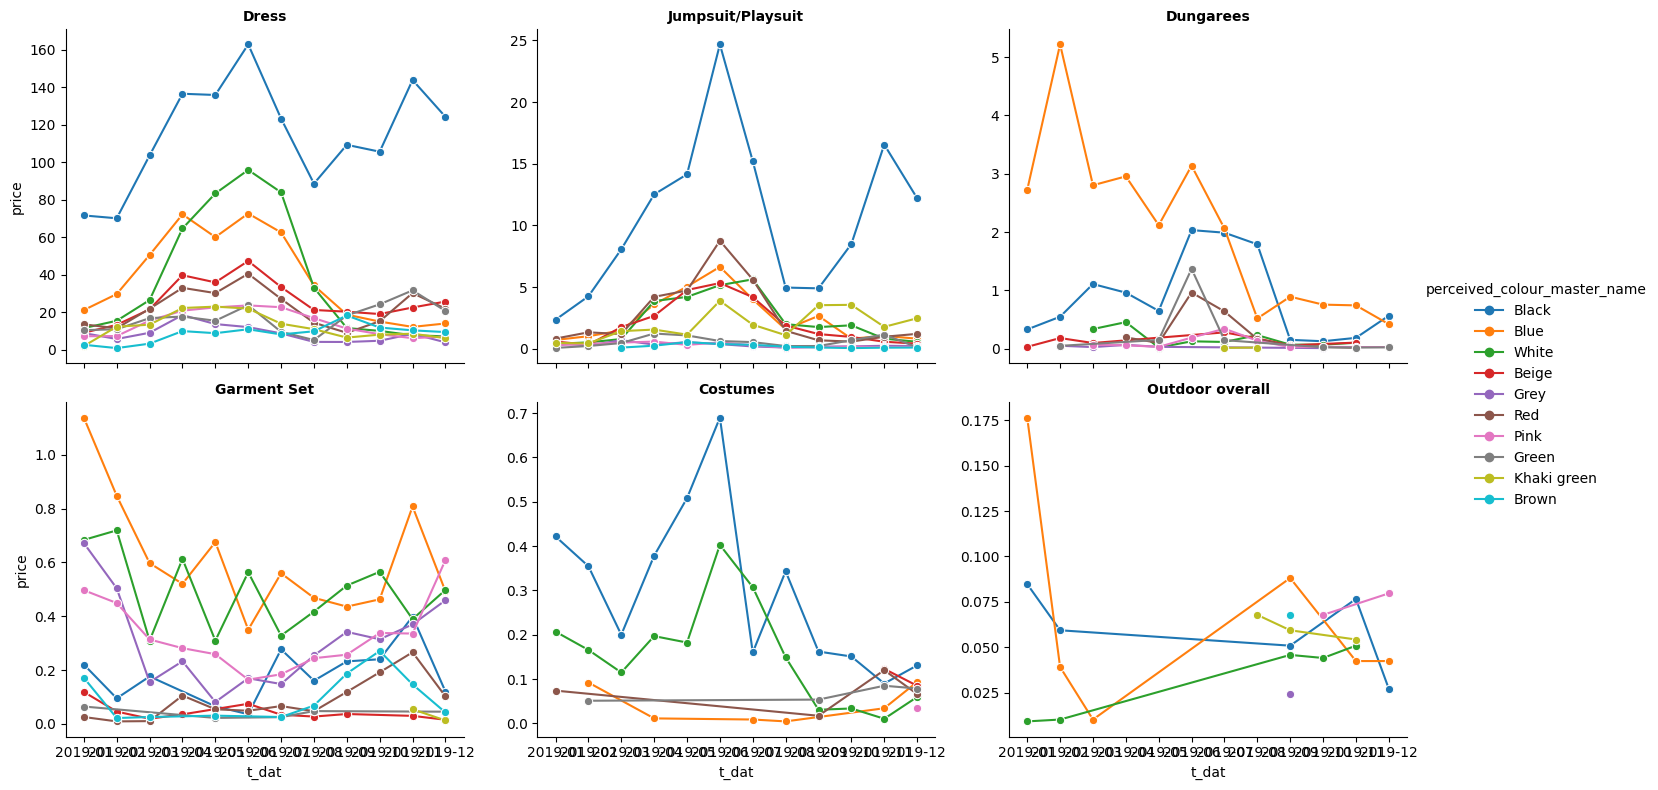

In [11]:
#'Garment Full body' 데이터만 추출 이후 lower와 동일
full_body_df = tr_cus_ar[tr_cus_ar["product_group_name"] == "Garment Full body"].copy()

top6_full_types = (
    full_body_df.groupby("product_type_name")["price"]
    .sum()
    .nlargest(6)
    .index.tolist()
)

full_body_top6 = full_body_df[full_body_df["product_type_name"].isin(top6_full_types)]

plt_full_data = full_body_top6.groupby(["t_dat", "product_type_name", "perceived_colour_master_name"])["price"].sum().reset_index()
plt_full_data["t_dat"] = plt_full_data["t_dat"].astype(str)

g = sb.relplot(
    data=plt_full_data,
    x="t_dat",
    y="price",
    hue="perceived_colour_master_name",
    hue_order=color_price2,
    col="product_type_name",
    col_order=top6_full_types,
    kind="line",
    marker="o",
    col_wrap=3,
    height=4,
    aspect=1.2,
    facet_kws={'sharey': False}
)
g.set_titles("{col_name}", fontweight='bold')
plt.show()

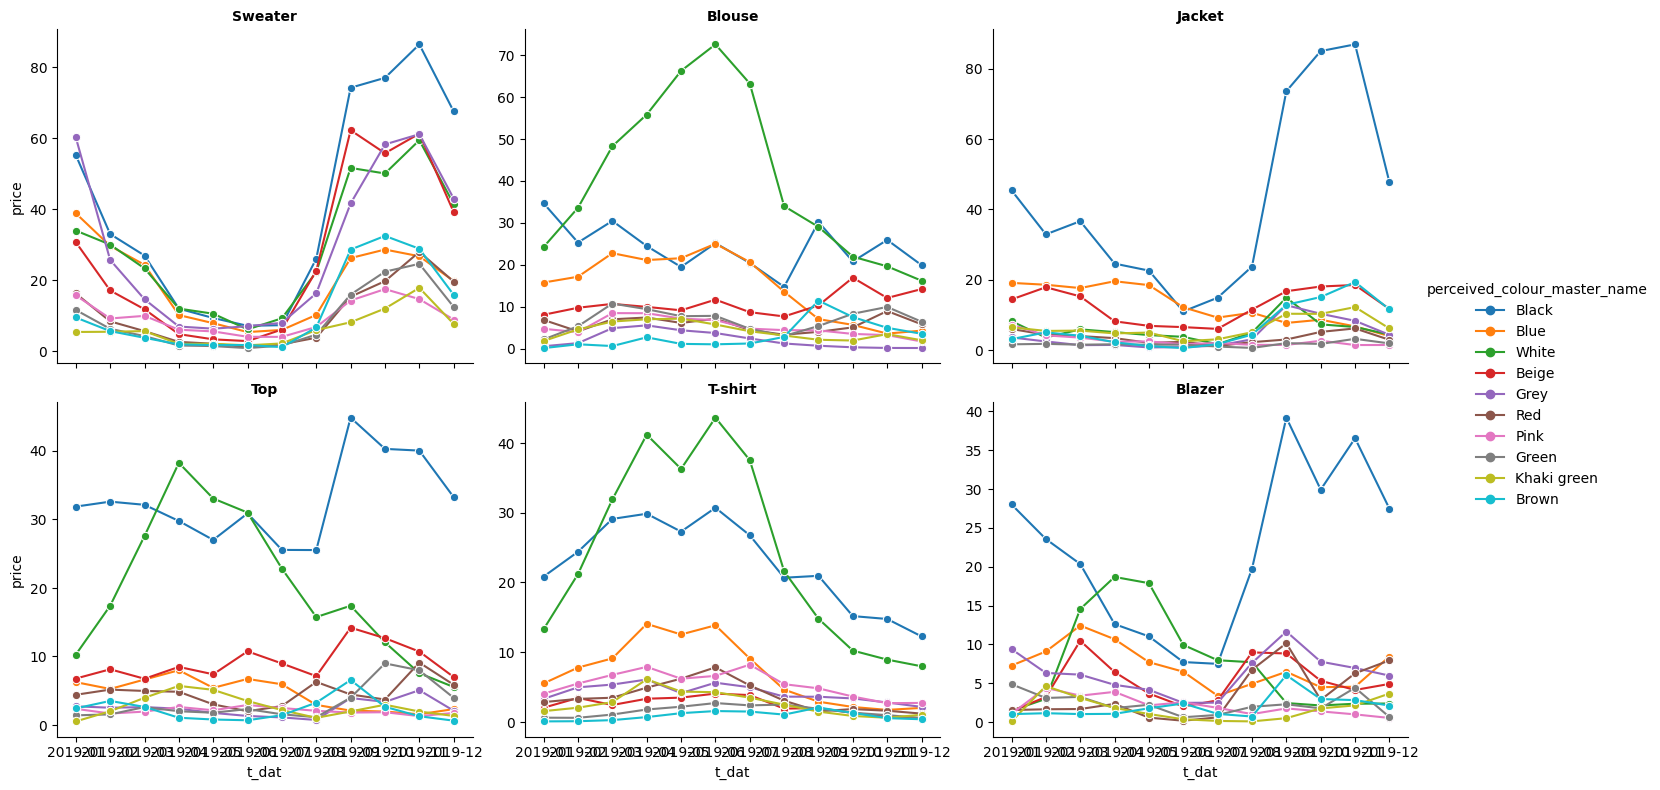

In [12]:
#'Garment Upper body' 데이터만 이후 lower와 동일
upper_body_df = tr_cus_ar[tr_cus_ar["product_group_name"] == "Garment Upper body"].copy()

top6_upper_types = (
    upper_body_df.groupby("product_type_name")["price"]
    .sum()
    .nlargest(6)
    .index.tolist()
)

upper_body_top6 = upper_body_df[upper_body_df["product_type_name"].isin(top6_upper_types)]

plt_upper_data = upper_body_top6.groupby(["t_dat", "product_type_name", "perceived_colour_master_name"])["price"].sum().reset_index()
plt_upper_data["t_dat"] = plt_upper_data["t_dat"].astype(str)

g = sb.relplot(
    data=plt_upper_data,
    x="t_dat",
    y="price",
    hue="perceived_colour_master_name",
    hue_order=color_price2,
    col="product_type_name",
    col_order=top6_upper_types,
    kind="line",
    marker="o",
    col_wrap=3,
    height=4,
    aspect=1.2,
    facet_kws={'sharey': False}
)
g.set_titles("{col_name}", fontweight='bold')
plt.show()

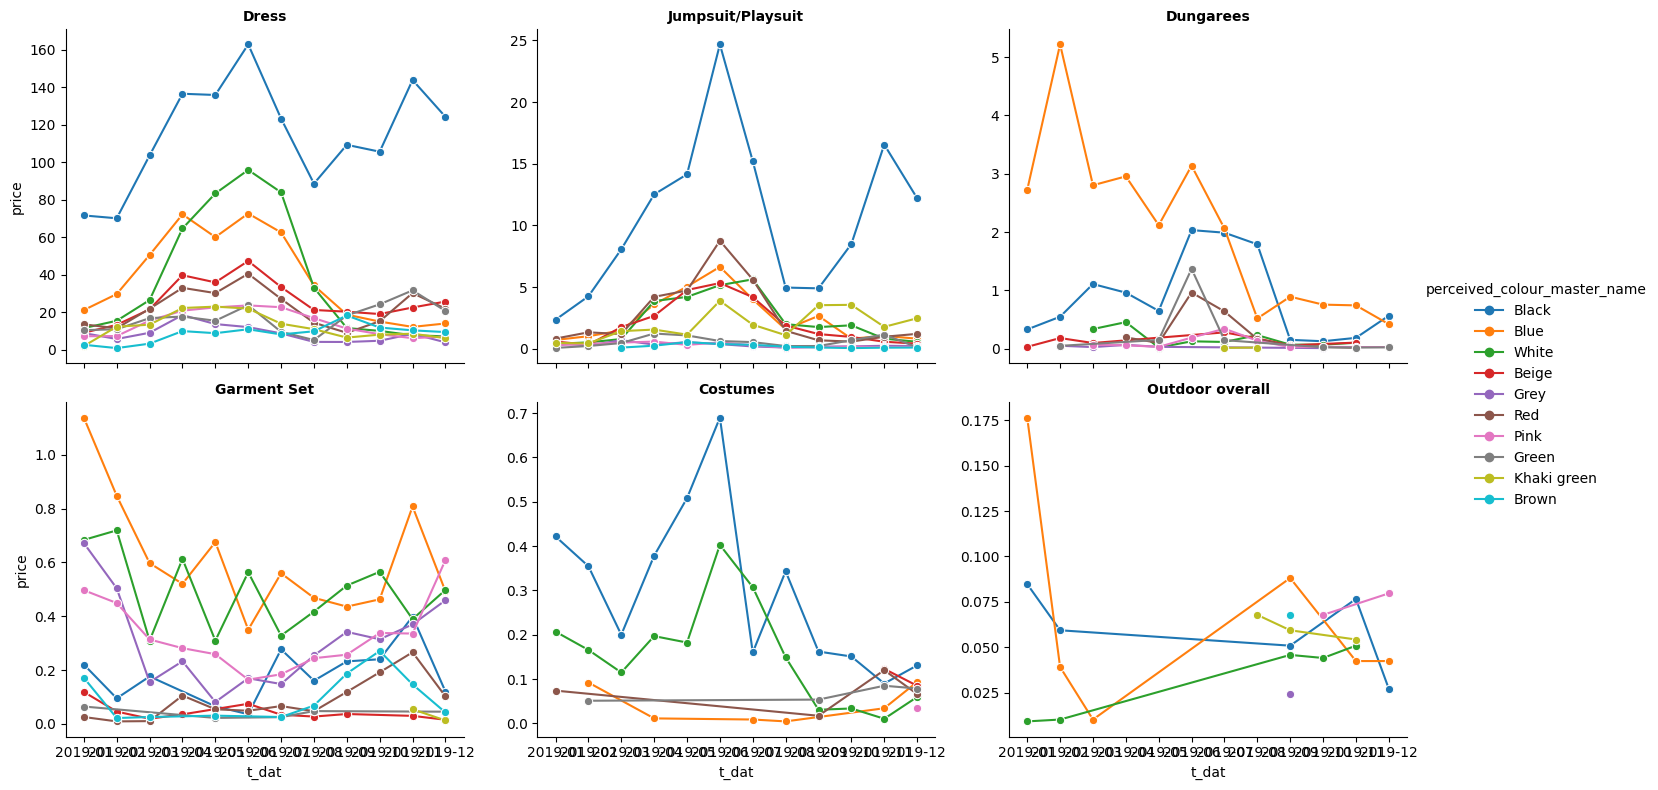

In [13]:
#'Garment Full body' 데이터만 추출 이후 lower와 동일
full_body_df = tr_cus_ar[tr_cus_ar["product_group_name"] == "Garment Full body"].copy()

top6_full_types = (
    full_body_df.groupby("product_type_name")["price"]
    .sum()
    .nlargest(6)
    .index.tolist()
)

full_body_top6 = full_body_df[full_body_df["product_type_name"].isin(top6_full_types)]

plt_full_data = full_body_top6.groupby(["t_dat", "product_type_name", "perceived_colour_master_name"])["price"].sum().reset_index()
plt_full_data["t_dat"] = plt_full_data["t_dat"].astype(str)

g = sb.relplot(
    data=plt_full_data,
    x="t_dat",
    y="price",
    hue="perceived_colour_master_name",
    hue_order=color_price2,
    col="product_type_name",
    col_order=top6_full_types,
    kind="line",
    marker="o",
    col_wrap=3,
    height=4,
    aspect=1.2,
    facet_kws={'sharey': False}
)
g.set_titles("{col_name}", fontweight='bold')
plt.show()